# Sesión 02 — Modelos de Clasificación: Ejercicios 1, 2 y 3
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona
**Estudiante:** *(escribe tu nombre aquí)*

**Dataset propio:** Heart Failure Prediction (Kaggle, fedesoriano) — 918 pacientes, 11 features clínicas, clasificación binaria (`HeartDisease`: 1 = enfermedad cardíaca, 0 = sano)

---

## Contenido y correspondencia con los ejercicios

| Sección | Contenido | Ejercicio |
|---|---|---|
| 1–4 | Entorno, carga, EDA y preparación de datos | 3 |
| 5–8 | Los 4 modelos de la sesión: Regresión Logística, Árbol de Decisión, SVM, KNN | 3 |
| 9 | Modelo adicional: **Random Forest** | 3 |
| 10–11 | Comparación (métricas, curvas ROC, matriz de selección) y justificación del mejor modelo | 3 |
| 12 | `GridSearchCV` para los modelos | **1** |
| 13 | Manejo de desbalance: `class_weight` y SMOTE | **2** |
| 14 | Conclusiones generales | 1, 2 y 3 |

> **Nota:** los enunciados de los Ejercicios 1 y 2 de este notebook están tomados de la versión de la sesión con *Breast Cancer* (GridSearchCV de los modelos y manejo de desbalance); aquí se aplican al dataset propio (Heart Failure). Los Ejercicios 1 y 2 de la versión con *Wine Quality* (GridSearchCV para SVM y clasificación multiclase) están en el notebook `Ejercicios_1_2_Wine_Quality.ipynb`. La clase de interés clínico es **Enfermo (1)**: el error más costoso es un **falso negativo** (paciente enfermo clasificado como sano), por lo que el **Recall** de la clase 1 es la métrica prioritaria.

---
## 1. Configuración del entorno

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    cross_validate, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
)

# imbalanced-learn (SMOTE) — se instala solo si no está disponible
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

RANDOM_STATE = 42
print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

**Heart Failure Prediction Dataset** (fedesoriano, Kaggle, 2021) integra cinco bases cardiológicas (Cleveland, Hungría, Suiza, Long Beach VA y Statlog). El autor unificó 11 variables comunes y eliminó duplicados, quedando **918 pacientes únicos**.

| Variable | Tipo | Descripción |
|---|---|---|
| `Age` | numérica | Edad (años) |
| `Sex` | categórica | M / F |
| `ChestPainType` | categórica | TA (angina típica), ATA (atípica), NAP (no anginosa), ASY (asintomático) |
| `RestingBP` | numérica | Presión arterial en reposo (mm Hg) |
| `Cholesterol` | numérica | Colesterol sérico (mg/dl) |
| `FastingBS` | binaria | Glucemia en ayunas > 120 mg/dl (1 / 0) |
| `RestingECG` | categórica | Normal, ST (anomalía onda ST-T), LVH (hipertrofia ventricular) |
| `MaxHR` | numérica | Frecuencia cardíaca máxima alcanzada |
| `ExerciseAngina` | categórica | Angina inducida por ejercicio (Y / N) |
| `Oldpeak` | numérica | Depresión del segmento ST |
| `ST_Slope` | categórica | Pendiente del segmento ST (Up, Flat, Down) |
| **`HeartDisease`** | **target** | **1 = enfermedad cardíaca, 0 = sano** |

**Cómo se carga:** el código busca primero un `heart.csv` local (sube el archivo en Colab si lo descargaste de Kaggle), luego un espejo público en GitHub y, como último recurso, `kagglehub`.

In [2]:
LOCAL_FILE = 'heart.csv'
MIRROR_URL = 'https://raw.githubusercontent.com/akarshsnair/Dataset-cart/main/heart.csv'

def load_heart():
    if os.path.exists(LOCAL_FILE):
        return pd.read_csv(LOCAL_FILE), 'archivo local'
    try:
        return pd.read_csv(MIRROR_URL), 'espejo GitHub'
    except Exception as e:
        print('Espejo no disponible, intentando kagglehub...', e)
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'])
        import kagglehub
        path = kagglehub.dataset_download('fedesoriano/heart-failure-prediction')
        return pd.read_csv(os.path.join(path, 'heart.csv')), 'kagglehub'

df, origen = load_heart()
assert df.shape[1] == 12 and 'HeartDisease' in df.columns, 'Estructura inesperada del CSV'
print(f'Dataset cargado desde: {origen}')
print(f'{df.shape[0]} pacientes, {df.shape[1] - 1} features + target')
df.head()

Dataset cargado desde: archivo local
918 pacientes, 11 features + target


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [3]:
print('Distribución de clases:')
print(df['HeartDisease'].value_counts().rename({0: 'Sano (0)', 1: 'Enfermo (1)'}))
print(f'\nProporción de enfermos: {df["HeartDisease"].mean():.1%}  |  sanos: {1 - df["HeartDisease"].mean():.1%}')
print(f'Ratio de desbalance: {(df["HeartDisease"] == 1).sum() / (df["HeartDisease"] == 0).sum():.2f}:1  → dataset casi balanceado')
df.describe().round(2)

Distribución de clases:
HeartDisease
Enfermo (1)    508
Sano (0)       410
Name: count, dtype: int64

Proporción de enfermos: 55.3%  |  sanos: 44.7%
Ratio de desbalance: 1.24:1  → dataset casi balanceado


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,917.0,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.7,0.23,136.81,0.89,0.55
std,9.43,18.51,109.4,0.42,25.46,1.07,0.50
min,28.00,0.00,0.0,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.0,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.0,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.0,0.00,156.00,1.50,1.00
max,77.00,200.00,603.0,1.00,202.00,6.20,1.00


### 2.1 Calidad de datos

En este dataset los valores faltantes suelen estar **codificados como 0** (colesterol y presión arterial no pueden ser 0 en una persona viva). Los verificamos antes de modelar.

In [4]:
print('Valores nulos por columna:')
nulos = df.isna().sum()
print(nulos[nulos > 0] if nulos.sum() else '  ninguno')
print(f'\nCholesterol = 0 : {(df["Cholesterol"] == 0).sum():4d} registros ({(df["Cholesterol"] == 0).mean():.1%})')
print(f'RestingBP   = 0 : {(df["RestingBP"] == 0).sum():4d} registro(s)')
print(f'Duplicados      : {df.duplicated().sum()}')

# Ceros imposibles → NaN (se imputarán DENTRO del pipeline para evitar fuga de información)
df_clean = df.copy()
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, np.nan)
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, np.nan)
print('\n→ Ceros imposibles convertidos a NaN. La imputación (mediana) se aprende solo con el train.')

# Validación de categorías: cualquier valor fuera del catálogo del diccionario de datos → NaN
VALID = {'Sex': {'M', 'F'}, 'ChestPainType': {'TA', 'ATA', 'NAP', 'ASY'},
         'RestingECG': {'Normal', 'ST', 'LVH'}, 'ExerciseAngina': {'Y', 'N'},
         'ST_Slope': {'Up', 'Flat', 'Down'}}
for col, ok in VALID.items():
    bad = df_clean[col].notna() & ~df_clean[col].isin(ok)
    if bad.any():
        print(f'⚠ {col}: {bad.sum()} valor(es) inválido(s) {df_clean.loc[bad, col].unique().tolist()} → NaN (se imputará con la moda)')
    df_clean.loc[~df_clean[col].isin(ok), col] = np.nan
print('\nNulos tras la limpieza:', df_clean.isna().sum()[df_clean.isna().sum() > 0].to_dict())

# Hallazgo: los ceros de colesterol NO son aleatorios
z = df['Cholesterol'] == 0
print(f'\nDe los {z.sum()} pacientes con Cholesterol = 0, el {df.loc[z, "HeartDisease"].mean():.0%} tiene enfermedad '
      f'(vs {df.loc[~z, "HeartDisease"].mean():.0%} en el resto) → el dato faltante es informativo (sesgo de origen de las bases).')

Valores nulos por columna:
Cholesterol       1
ExerciseAngina    1
dtype: int64

Cholesterol = 0 :  172 registros (18.7%)
RestingBP   = 0 :    1 registro(s)
Duplicados      : 0

→ Ceros imposibles convertidos a NaN. La imputación (mediana) se aprende solo con el train.
⚠ ST_Slope: 1 valor(es) inválido(s) ['t'] → NaN (se imputará con la moda)

Nulos tras la limpieza: {'RestingBP': 1, 'Cholesterol': 173, 'ExerciseAngina': 1, 'ST_Slope': 1}

De los 172 pacientes con Cholesterol = 0, el 88% tiene enfermedad (vs 48% en el resto) → el dato faltante es informativo (sesgo de origen de las bases).


> **Sobre la fuente de datos:** el dataset original de Kaggle no tiene nulos. Si cargas la copia espejo de GitHub, pueden aparecer 1–3 celdas corruptas (p. ej. `'t'` en `ST_Slope`); la celda anterior las detecta y las trata como faltantes, así que el resultado es equivalente.

---
## 3. Análisis exploratorio orientado a clasificación

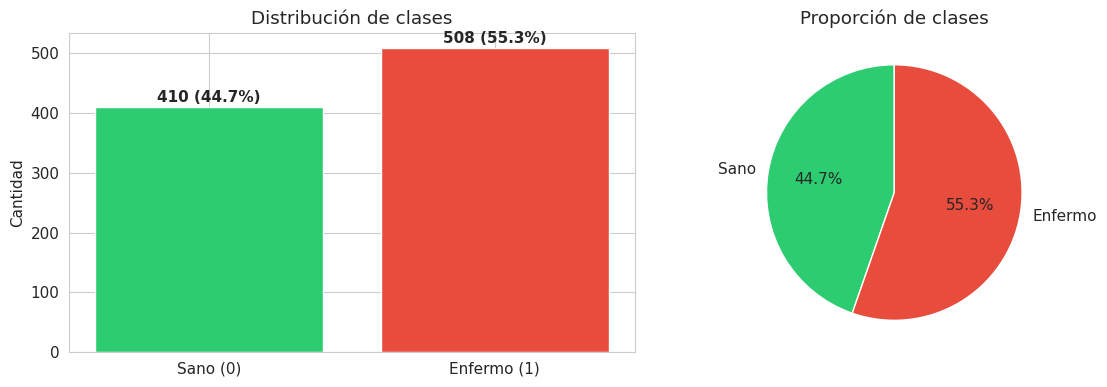

In [5]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ecc71', '#e74c3c']
counts = df['HeartDisease'].value_counts().sort_index()
axes[0].bar(['Sano (0)', 'Enfermo (1)'], counts.values, color=colors)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 8, f'{v} ({v / len(df):.1%})', ha='center', fontweight='bold')
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[1].pie(counts.values, labels=['Sano', 'Enfermo'], colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de clases')
plt.tight_layout()
plt.show()

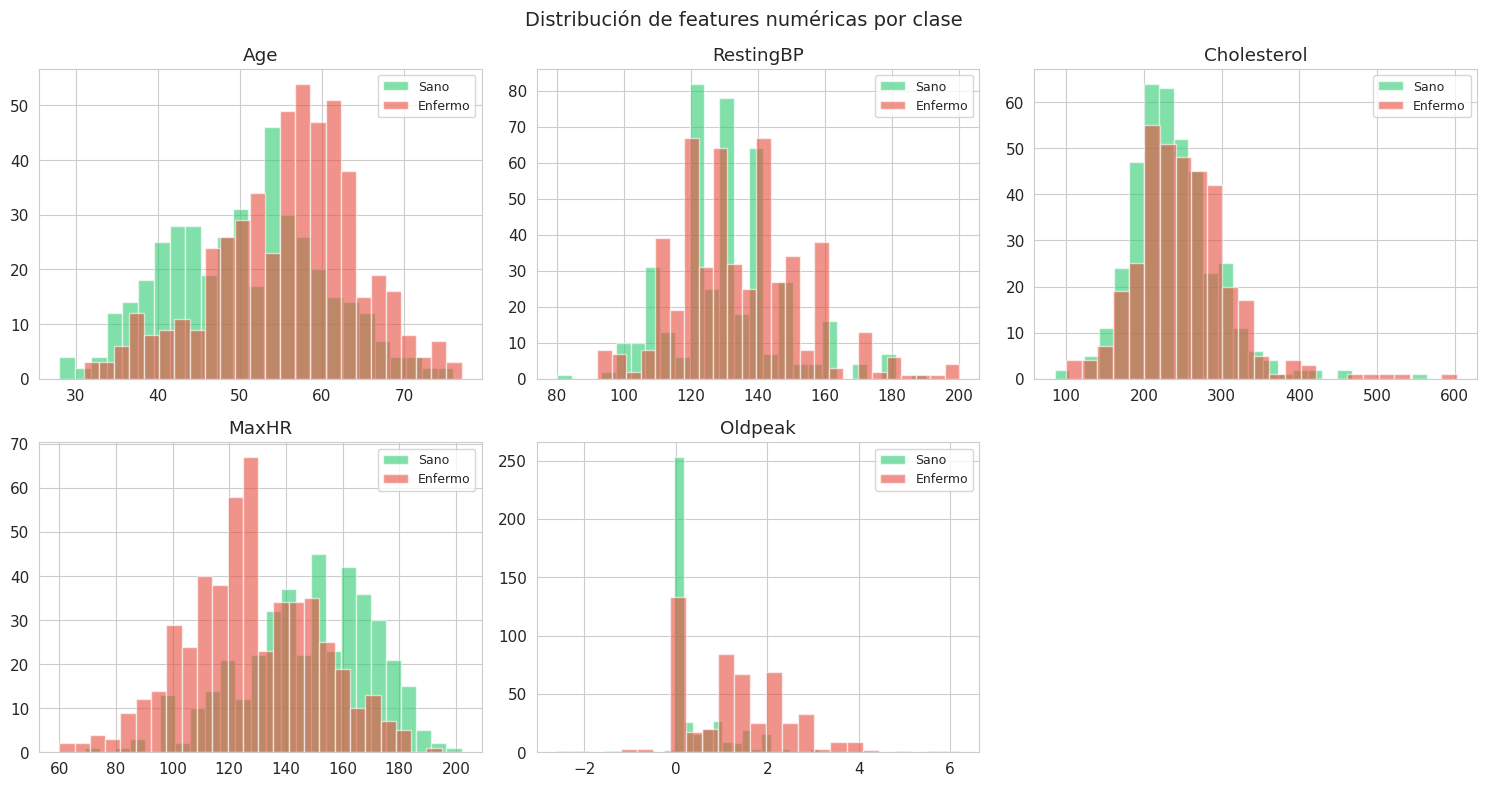

In [6]:
# 3.2  Features numéricas por clase
NUM = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(NUM):
    ax = axes[i // 3, i % 3]
    for label, color, nombre in zip([0, 1], colors, ['Sano', 'Enfermo']):
        ax.hist(df_clean.loc[df_clean['HeartDisease'] == label, feat].dropna(),
                bins=25, alpha=0.6, color=color, label=nombre)
    ax.set_title(feat)
    ax.legend(fontsize=9)
axes[1, 2].set_visible(False)
plt.suptitle('Distribución de features numéricas por clase', fontsize=14)
plt.tight_layout()
plt.show()

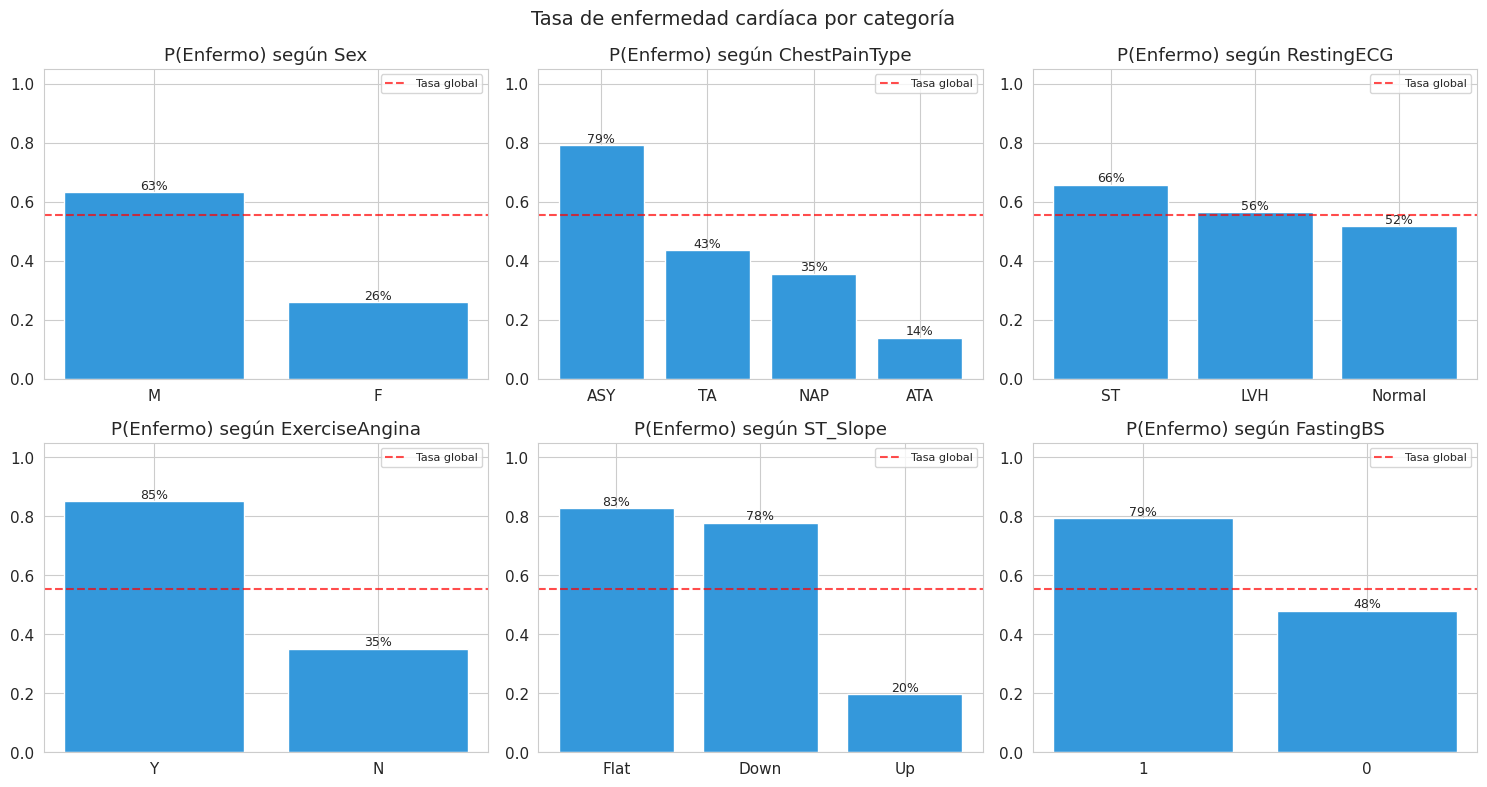

In [7]:
# 3.3  Features categóricas: tasa de enfermedad por categoría
CAT = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
BIN = ['FastingBS']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(CAT + BIN):
    ax = axes[i // 3, i % 3]
    tasa = df_clean.groupby(feat)['HeartDisease'].mean().sort_values(ascending=False)
    ax.bar(tasa.index.astype(str), tasa.values, color='#3498db')
    ax.axhline(df_clean['HeartDisease'].mean(), color='red', linestyle='--', alpha=0.7, label='Tasa global')
    for j, v in enumerate(tasa.values):
        ax.text(j, v + 0.01, f'{v:.0%}', ha='center', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'P(Enfermo) según {feat}')
    ax.legend(fontsize=8)
plt.suptitle('Tasa de enfermedad cardíaca por categoría', fontsize=14)
plt.tight_layout()
plt.show()

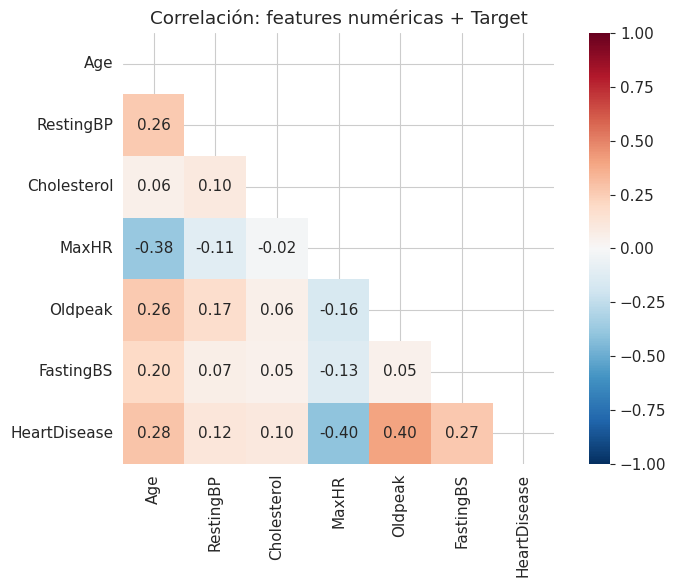

In [8]:
# 3.4  Matriz de correlación (numéricas + target)
plt.figure(figsize=(8, 6))
corr = df_clean[NUM + BIN + ['HeartDisease']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True)
plt.title('Correlación: features numéricas + Target')
plt.tight_layout()
plt.show()

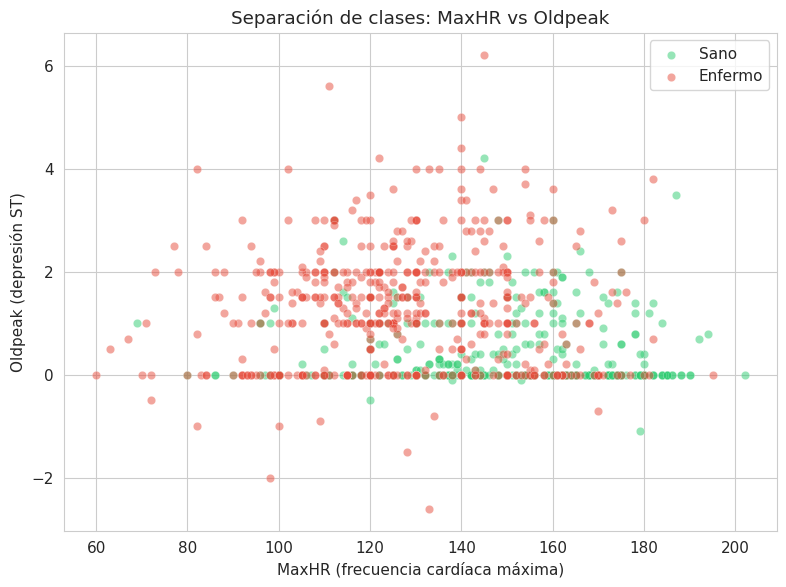

In [9]:
# 3.5  Scatter: dos features muy discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, nombre in zip([0, 1], colors, ['Sano', 'Enfermo']):
    m = df_clean['HeartDisease'] == label
    ax.scatter(df_clean.loc[m, 'MaxHR'], df_clean.loc[m, 'Oldpeak'],
               alpha=0.5, c=color, label=nombre, edgecolors='w', linewidth=0.3)
ax.set_xlabel('MaxHR (frecuencia cardíaca máxima)')
ax.set_ylabel('Oldpeak (depresión ST)')
ax.set_title('Separación de clases: MaxHR vs Oldpeak')
ax.legend()
plt.tight_layout()
plt.show()

### Hallazgos del EDA

- **Clases casi balanceadas** (55 % enfermos / 45 % sanos): la accuracy es una métrica razonable aquí, aunque se prioriza Recall, F1 y AUC por el costo clínico del falso negativo.
- **Variables categóricas muy discriminantes:** la tasa de enfermedad es **85 % con angina inducida por ejercicio** (vs 35 % sin ella), **79 % con dolor torácico asintomático (ASY)** (vs 14 % con angina atípica), **83 % / 78 % con pendiente ST plana / descendente** (vs 20 % ascendente) y **63 % en hombres** (vs 26 % en mujeres).
- **Numéricas:** los enfermos tienen menor frecuencia cardíaca máxima (≈128 vs 148 lpm), mayor `Oldpeak` (≈1.27 vs 0.41) y son mayores (≈56 vs 51 años). Las correlaciones más fuertes con el target son `Oldpeak` (+0.40), `MaxHR` (−0.40) y `Age` (+0.28); ninguna supera |0.41|, por lo que **ninguna variable separa las clases por sí sola**.
- **Colesterol = 0 no es un dato faltante aleatorio:** el 88 % de esos 172 pacientes tiene enfermedad (vs 48 % en el resto). Probablemente refleja el origen de los datos (algunas bases hospitalarias no registraron colesterol). Se imputa con la mediana, pero conviene tenerlo presente como **posible sesgo de origen** al interpretar los resultados.

---
## 4. Preparación de datos

Dado que hay variables **categóricas** y **valores faltantes**, todo el preprocesamiento se encapsula en un `ColumnTransformer` dentro de cada `Pipeline`. Así los parámetros (medianas, medias, categorías) se aprenden **solo con los datos de entrenamiento de cada fold**, evitando fuga de información (*data leakage*).

| Grupo | Variables | Tratamiento |
|---|---|---|
| Numéricas | Age, RestingBP, Cholesterol, MaxHR, Oldpeak | Imputación por mediana + `StandardScaler` (solo si el modelo es sensible a escala) |
| Binaria | FastingBS | Sin cambios |
| Categóricas | Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope | Imputación por moda + One-Hot Encoding |

Los modelos **basados en distancia o gradiente** (Regresión Logística, SVM, KNN) usan estandarización; los **basados en árboles** (Árbol, Random Forest) no la necesitan.

In [10]:
# 4.1  Separación features / target y split estratificado 80/20
FEATURES = NUM + BIN + CAT
X = df_clean[FEATURES].copy()
y = df_clean['HeartDisease'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción de enfermos en train: {y_train.mean():.1%}')
print(f'Proporción de enfermos en test:  {y_test.mean():.1%}')

# Validación cruzada estratificada (5 folds) — se usa siempre sobre el train
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Entrenamiento: 734 muestras
Test:          184 muestras

Proporción de enfermos en train: 55.3%
Proporción de enfermos en test:  55.4%


In [11]:
# 4.2  Preprocesador reutilizable
def make_prep(scale=True):
    """ColumnTransformer: imputación + (escalado) + one-hot. scale=False para modelos de árboles."""
    num_steps = [('imp', SimpleImputer(strategy='median'))]
    if scale:
        num_steps.append(('sc', StandardScaler()))
    return ColumnTransformer([
        ('num', Pipeline(num_steps), NUM),
        ('bin', 'passthrough', BIN),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False))
        ]), CAT),
    ], verbose_feature_names_out=False)

def make_pipe(clf, scale=True):
    return Pipeline([('prep', make_prep(scale)), ('clf', clf)])

def feat_names(pipe):
    """Nombres de las features tras el preprocesamiento (incluye dummies)."""
    return list(pipe.named_steps['prep'].get_feature_names_out())

# Registros globales que se irán llenando en cada sección
MODELS = {}     # nombre → pipeline entrenado
CV = {}         # nombre → resultados de validación cruzada
METRICS = {}    # nombre → métricas en test
print('✓ Preprocesador definido')

✓ Preprocesador definido


### Funciones auxiliares para evaluación de clasificadores

In [12]:
def get_score(model, X_te):
    """Puntaje continuo de la clase positiva (para ROC/AUC)."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_te)[:, 1]
    return model.decision_function(X_te)

def cv_report(pipe, name, cv=skf):
    """Validación cruzada 5-fold sobre train con 5 métricas; guarda el resultado en CV."""
    res = cross_validate(pipe, X_train, y_train, cv=cv,
                         scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                         return_train_score=True)
    CV[name] = res
    print(f'{name} — Cross-Validation (5-fold)')
    for m, lab in [('accuracy', 'Accuracy'), ('precision', 'Precision'), ('recall', 'Recall'),
                   ('f1', 'F1-Score'), ('roc_auc', 'AUC')]:
        print(f'  {lab:10s}: {res["test_" + m].mean():.4f} ± {res["test_" + m].std():.4f}')
    return res

def eval_classifier(model, X_te, y_te, model_name='Modelo'):
    """Métricas en test, matriz de confusión, desglose FN/FP y reporte."""
    y_pred = model.predict(X_te)
    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred),
        'AUC':       roc_auc_score(y_te, get_score(model, X_te)),
    }
    METRICS[model_name] = metrics

    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    tn, fp, fn, tp = cm.ravel()
    labels = ['TN\n(sano\ncorrecto)', 'FP\n(sano→\nenfermo)', 'FN\n(enfermo→\nsano)', 'TP\n(enfermo\ncorrecto)']
    axes[1].bar(labels, [tn, fp, fn, tp], color=['#2ecc71', '#f39c12', '#e74c3c', '#3498db'])
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')
    plt.tight_layout()
    plt.show()

    print(f'\n  FN (enfermo NO detectado): {fn}   ← error más costoso')
    print(f'  FP (sano marcado enfermo): {fp}')
    print('\nReporte completo:')
    print(classification_report(y_te, y_pred, target_names=['Sano', 'Enfermo']))
    return metrics

def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    """Curva ROC de un modelo."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    fpr, tpr, _ = roc_curve(y_te, get_score(model, X_te))
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend(loc='lower right')
    return roc_auc

print('✓ Funciones auxiliares definidas')

✓ Funciones auxiliares definidas


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss con regularización L2 por defecto.

In [13]:
# 5.1  Pipeline + validación cruzada
pipe_lr = make_pipe(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), scale=True)
cv_report(pipe_lr, 'Regresión Logística')

pipe_lr.fit(X_train, y_train)
MODELS['Regresión Logística'] = pipe_lr

Regresión Logística — Cross-Validation (5-fold)
  Accuracy  : 0.8474 ± 0.0299
  Precision : 0.8616 ± 0.0457
  Recall    : 0.8671 ± 0.0222
  F1-Score  : 0.8633 ± 0.0226
  AUC       : 0.9219 ± 0.0348


=== Regresión Logística ===
  Accuracy: 0.8859
  Precision: 0.8857
  Recall: 0.9118
  F1-Score: 0.8986
  AUC: 0.9322


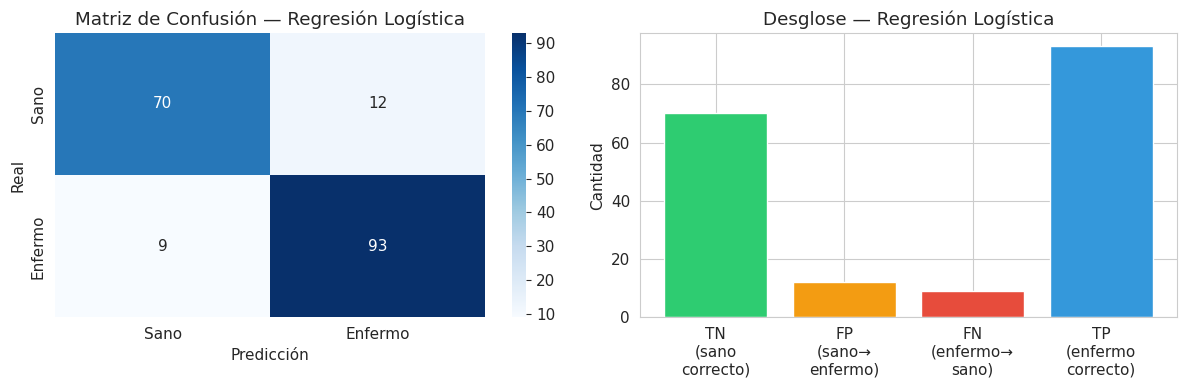


  FN (enfermo NO detectado): 9   ← error más costoso
  FP (sano marcado enfermo): 12

Reporte completo:
              precision    recall  f1-score   support

        Sano       0.89      0.85      0.87        82
     Enfermo       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [14]:
# 5.2  Evaluación completa en test
_ = eval_classifier(pipe_lr, X_test, y_test, 'Regresión Logística')

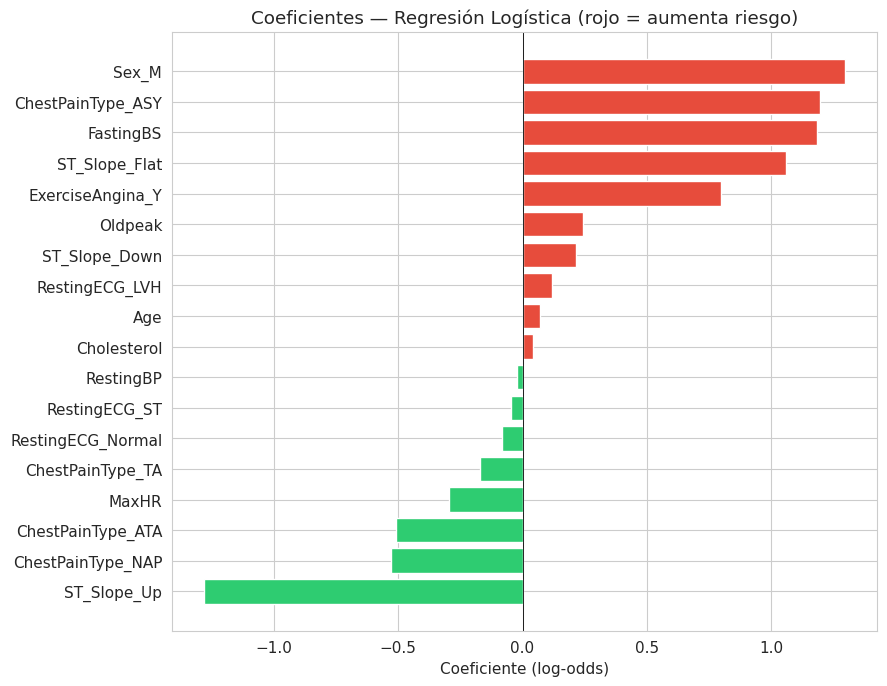

Interpretación:
  → Features que más aumentan la probabilidad de ENFERMEDAD: ['Sex_M', 'ChestPainType_ASY', 'FastingBS']
  → Features que más la reducen (protectoras):               ['ST_Slope_Up', 'ChestPainType_NAP', 'ChestPainType_ATA']

Odds ratio (exp(coef)) de las 3 features de mayor riesgo:
Sex_M                3.66
ChestPainType_ASY    3.32
FastingBS            3.28


In [15]:
# 5.3  Coeficientes estandarizados y odds ratios
coefs = pd.Series(pipe_lr.named_steps['clf'].coef_[0], index=feat_names(pipe_lr)).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(coefs.index, coefs.values, color=['#2ecc71' if c < 0 else '#e74c3c' for c in coefs])
ax.set_title('Coeficientes — Regresión Logística (rojo = aumenta riesgo)')
ax.set_xlabel('Coeficiente (log-odds)')
ax.axvline(0, color='black', linewidth=0.6)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más aumentan la probabilidad de ENFERMEDAD: {coefs.tail(3).index.tolist()[::-1]}')
print(f'  → Features que más la reducen (protectoras):               {coefs.head(3).index.tolist()}')
print('\nOdds ratio (exp(coef)) de las 3 features de mayor riesgo:')
print(np.exp(coefs.tail(3))[::-1].round(2).to_string())

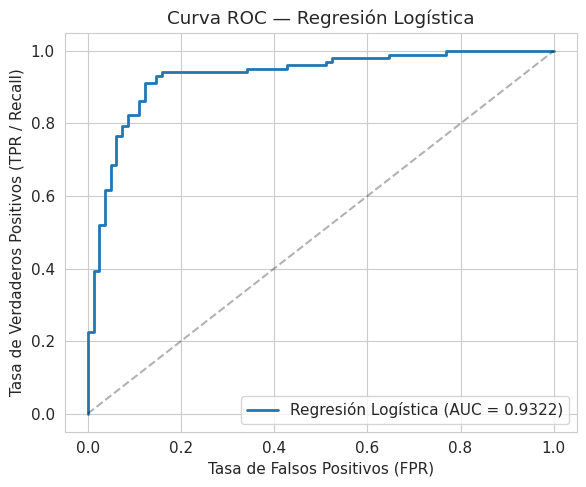

AUC: 0.9322


In [16]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr:.4f}')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo elige la feature y el umbral que maximizan la reducción de impureza (Gini: G(t) = 1 − Σpₖ²). Las particiones son ortogonales a los ejes. No requiere estandarización.

In [17]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE), scale=False)
cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=['accuracy', 'f1', 'recall'], return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Val   Accuracy: {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Val   F1-Score: {cv_dt_full["test_f1"].mean():.4f} ± {cv_dt_full["test_f1"].std():.4f}')
print('\n⚠ Train accuracy ≈ 1.0 con validación mucho menor indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Val   Accuracy: 0.7929 ± 0.0542
  Val   F1-Score: 0.8078 ± 0.0552

⚠ Train accuracy ≈ 1.0 con validación mucho menor indica sobreajuste


In [18]:
# 6.2  Árbol con pre-poda
pipe_dt = make_pipe(DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                           min_samples_leaf=5, random_state=RANDOM_STATE), scale=False)
cv_report(pipe_dt, 'Árbol de Decisión')
print(f'  Train Acc : {CV["Árbol de Decisión"]["train_accuracy"].mean():.4f}  (brecha train–val menor que sin poda)')

pipe_dt.fit(X_train, y_train)
MODELS['Árbol de Decisión'] = pipe_dt

Árbol de Decisión — Cross-Validation (5-fold)
  Accuracy  : 0.8066 ± 0.0266
  Precision : 0.8519 ± 0.0453
  Recall    : 0.7932 ± 0.0581
  F1-Score  : 0.8188 ± 0.0268
  AUC       : 0.8703 ± 0.0379
  Train Acc : 0.8924  (brecha train–val menor que sin poda)


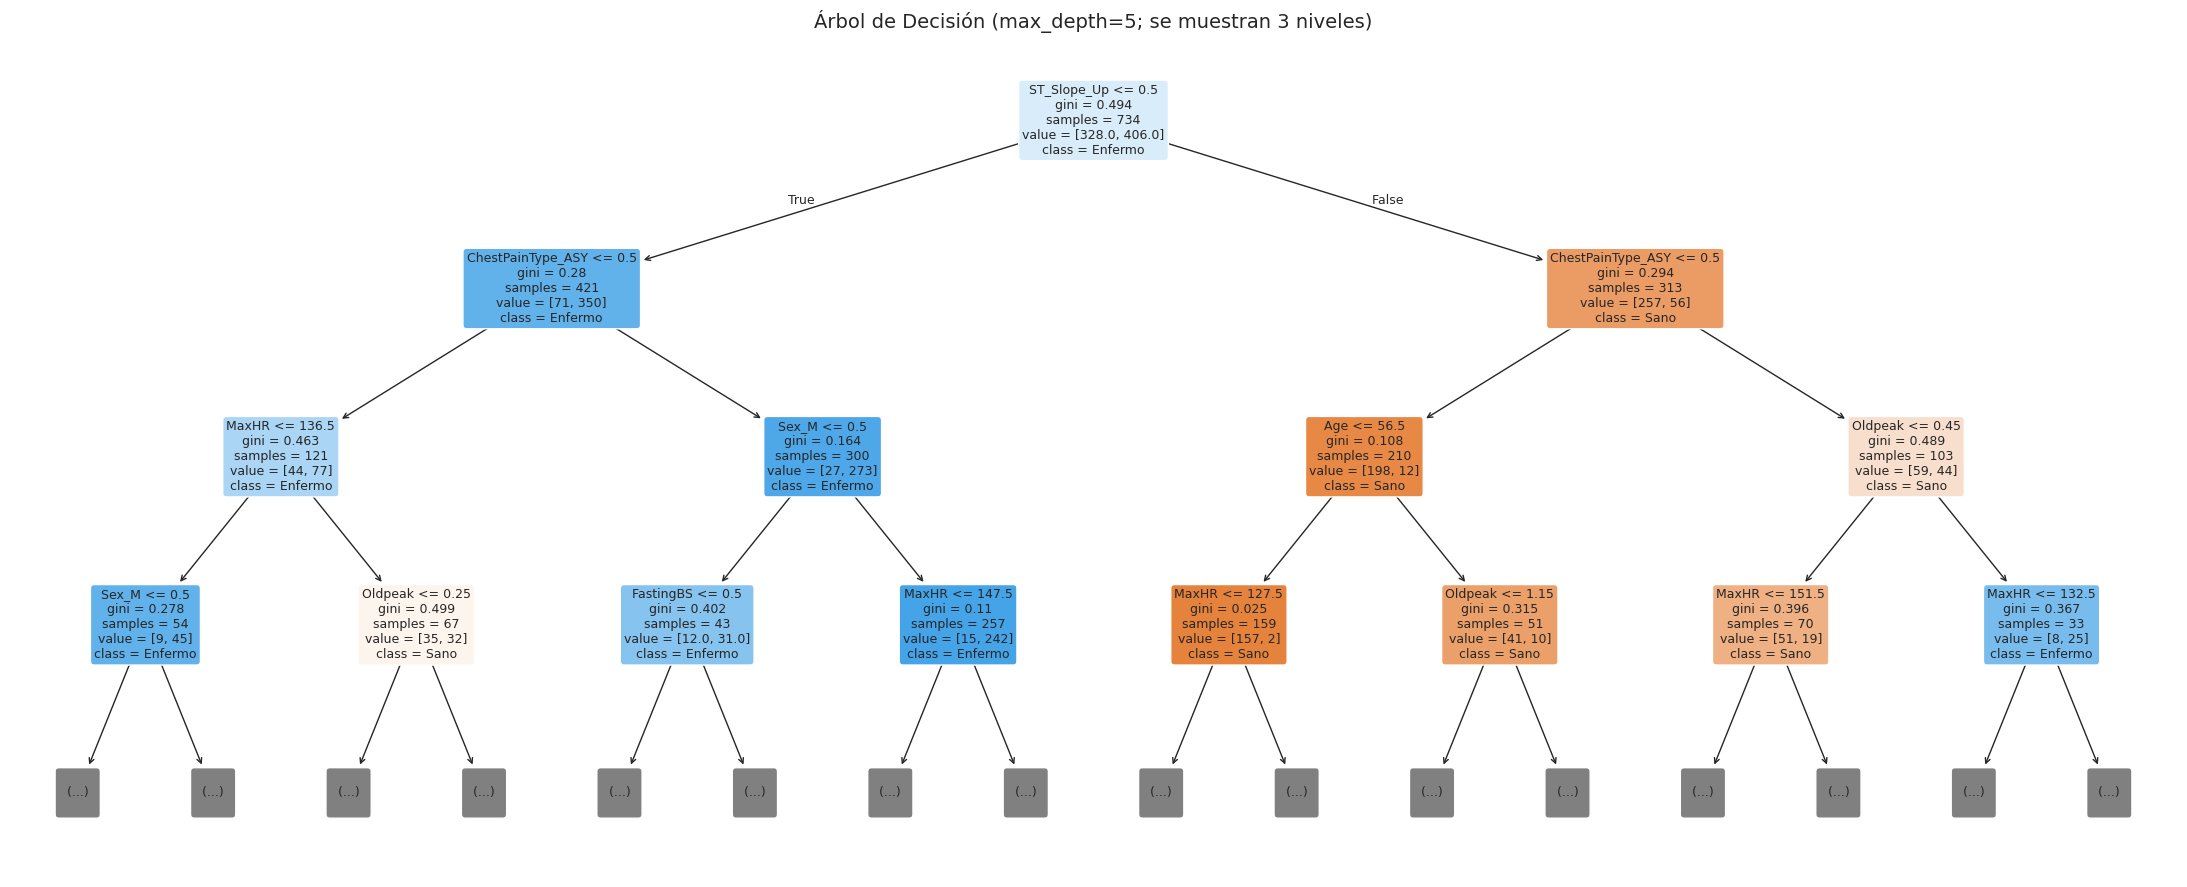

In [19]:
# 6.3  Visualización del árbol podado (3 primeros niveles para legibilidad)
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(pipe_dt.named_steps['clf'], feature_names=feat_names(pipe_dt),
          class_names=['Sano', 'Enfermo'], filled=True, rounded=True,
          fontsize=9, ax=ax, max_depth=3)
ax.set_title('Árbol de Decisión (max_depth=5; se muestran 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.7826
  Precision: 0.8229
  Recall: 0.7745
  F1-Score: 0.7980
  AUC: 0.8505


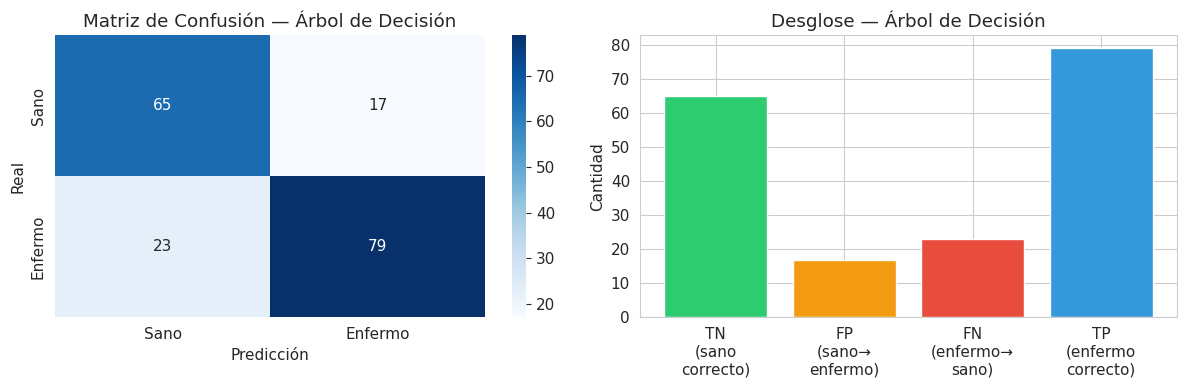


  FN (enfermo NO detectado): 23   ← error más costoso
  FP (sano marcado enfermo): 17

Reporte completo:
              precision    recall  f1-score   support

        Sano       0.74      0.79      0.76        82
     Enfermo       0.82      0.77      0.80       102

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.79      0.78      0.78       184



In [20]:
# 6.4  Evaluación completa
_ = eval_classifier(pipe_dt, X_test, y_test, 'Árbol de Decisión')

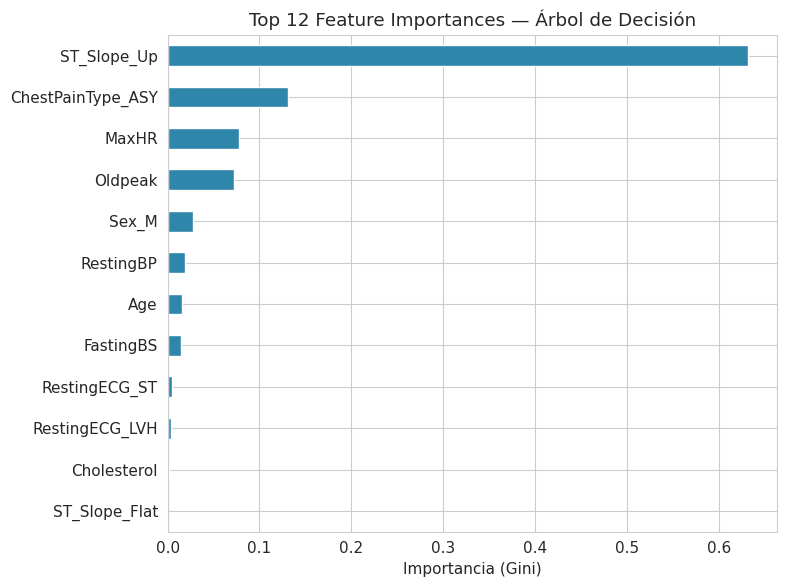

In [21]:
# 6.5  Importancia de features (Gini)
imp_dt = pd.Series(pipe_dt.named_steps['clf'].feature_importances_,
                   index=feat_names(pipe_dt)).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
imp_dt.tail(12).plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 12 Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

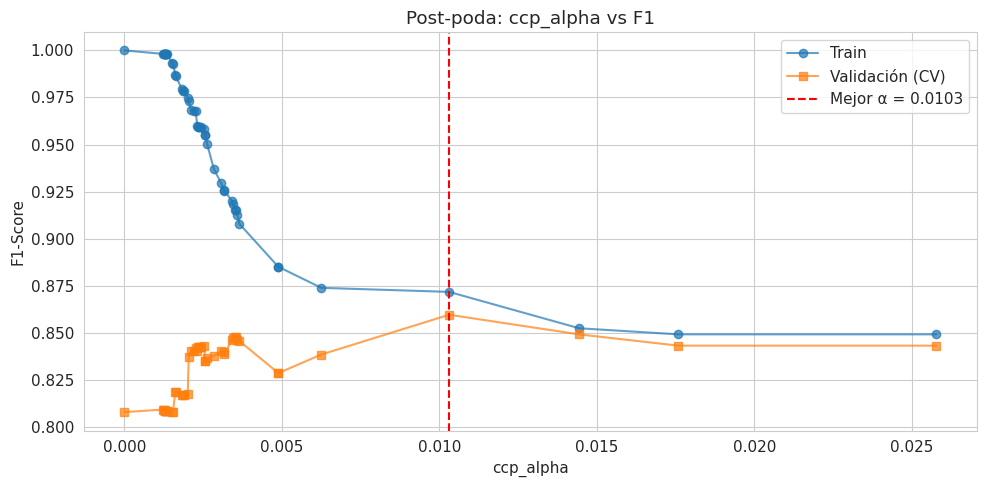

Mejor ccp_alpha: 0.010309  →  F1 CV = 0.8595


In [22]:
# 6.6  Post-poda con ccp_alpha (métrica: F1 en validación cruzada)
Xt = make_prep(False).fit_transform(X_train)
path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(Xt, y_train)
alphas = np.unique(np.round(path.ccp_alphas[:-1], 6))
alphas = alphas[::max(1, len(alphas) // 25)]   # ~25 valores para acelerar

tr_s, va_s = [], []
for a in alphas:
    r = cross_validate(make_pipe(DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE), scale=False),
                       X_train, y_train, cv=skf, scoring='f1', return_train_score=True)
    tr_s.append(r['train_score'].mean()); va_s.append(r['test_score'].mean())

best_a = alphas[int(np.argmax(va_s))]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, tr_s, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, va_s, 's-', label='Validación (CV)', alpha=0.7)
ax.axvline(best_a, color='red', linestyle='--', label=f'Mejor α = {best_a:.4f}')
ax.set_xlabel('ccp_alpha'); ax.set_ylabel('F1-Score')
ax.set_title('Post-poda: ccp_alpha vs F1')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {best_a:.6f}  →  F1 CV = {max(va_s):.4f}')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca el hiperplano de máximo margen γ = 2/‖w‖. Con margen suave permite violaciones controladas: min ½‖w‖² + C·Σξᵢ. El *kernel trick* maneja fronteras no lineales. Es **sensible a la escala**.

In [23]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = make_pipe(SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE), scale=True)
cv_report(pipe_svm, 'SVM (RBF)')

pipe_svm.fit(X_train, y_train)
MODELS['SVM (RBF)'] = pipe_svm

SVM (RBF) — Cross-Validation (5-fold)
  Accuracy  : 0.8502 ± 0.0361
  Precision : 0.8500 ± 0.0520
  Recall    : 0.8917 ± 0.0281
  F1-Score  : 0.8689 ± 0.0264
  AUC       : 0.9174 ± 0.0334


=== SVM (RBF) ===
  Accuracy: 0.8641
  Precision: 0.8738
  Recall: 0.8824
  F1-Score: 0.8780
  AUC: 0.9359


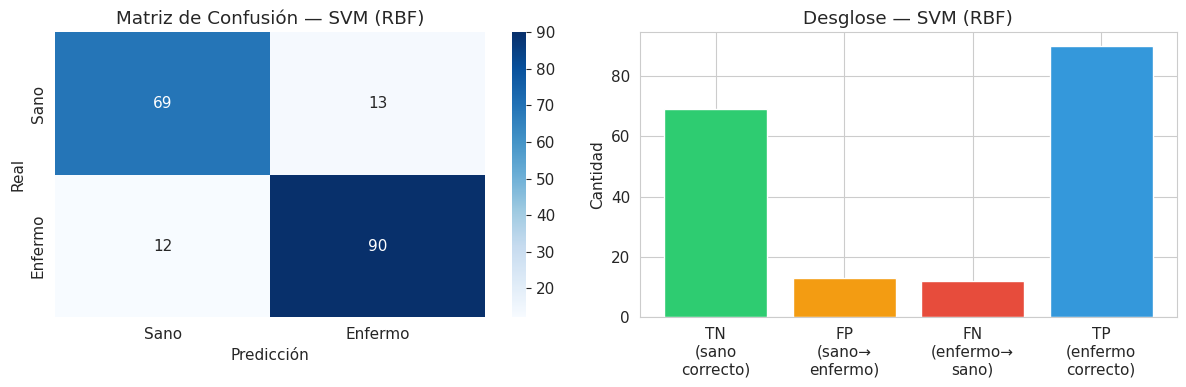


  FN (enfermo NO detectado): 12   ← error más costoso
  FP (sano marcado enfermo): 13

Reporte completo:
              precision    recall  f1-score   support

        Sano       0.85      0.84      0.85        82
     Enfermo       0.87      0.88      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [24]:
# 7.2  Evaluación completa
_ = eval_classifier(pipe_svm, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : F1 = 0.8662


  Kernel rbf     : F1 = 0.8689


  Kernel poly    : F1 = 0.8683


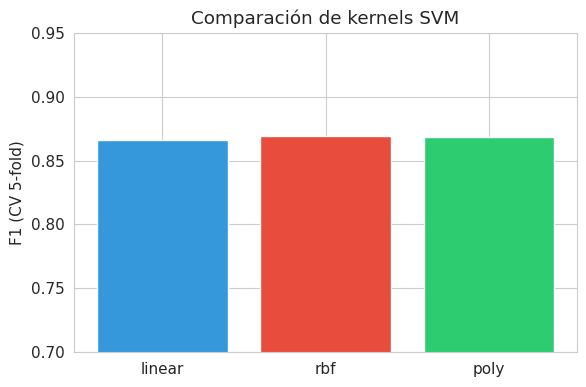

In [25]:
# 7.3  Comparación de kernels
kernel_results = {}
for k in ['linear', 'rbf', 'poly']:
    r = cross_validate(make_pipe(SVC(kernel=k, C=1.0, random_state=RANDOM_STATE), scale=True),
                       X_train, y_train, cv=skf, scoring='f1')
    kernel_results[k] = r['test_score'].mean()
    print(f'  Kernel {k:8s}: F1 = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('F1 (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.7, 0.95)
plt.tight_layout()
plt.show()

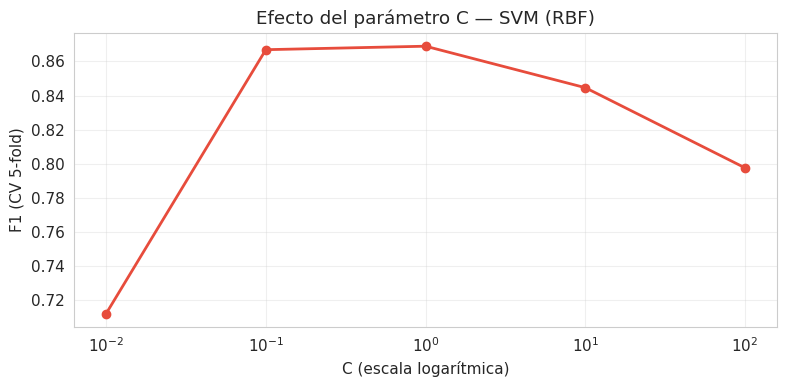

Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [26]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []
for c in C_values:
    r = cross_validate(make_pipe(SVC(kernel='rbf', C=c, random_state=RANDOM_STATE), scale=True),
                       X_train, y_train, cv=skf, scoring='f1')
    c_scores.append(r['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)'); ax.set_ylabel('F1 (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Interpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Aprendizaje basado en instancias (*lazy learning*). Clasifica por voto mayoritario de los K vecinos más cercanos según la distancia Euclidiana. Sensible a la escala y a la dimensionalidad. Con las variables one-hot, la distancia también refleja diferencias categóricas.

In [27]:
# 8.1  Pipeline KNN (K=5 de referencia)
pipe_knn = make_pipe(KNeighborsClassifier(n_neighbors=5), scale=True)
cv_report(pipe_knn, 'KNN (K=5)')

pipe_knn.fit(X_train, y_train)
MODELS['KNN (K=5)'] = pipe_knn

KNN (K=5) — Cross-Validation (5-fold)
  Accuracy  : 0.8338 ± 0.0541
  Precision : 0.8441 ± 0.0645
  Recall    : 0.8646 ± 0.0217
  F1-Score  : 0.8533 ± 0.0416
  AUC       : 0.8972 ± 0.0391


=== KNN (K=5) ===
  Accuracy: 0.8424
  Precision: 0.8614
  Recall: 0.8529
  F1-Score: 0.8571
  AUC: 0.9278


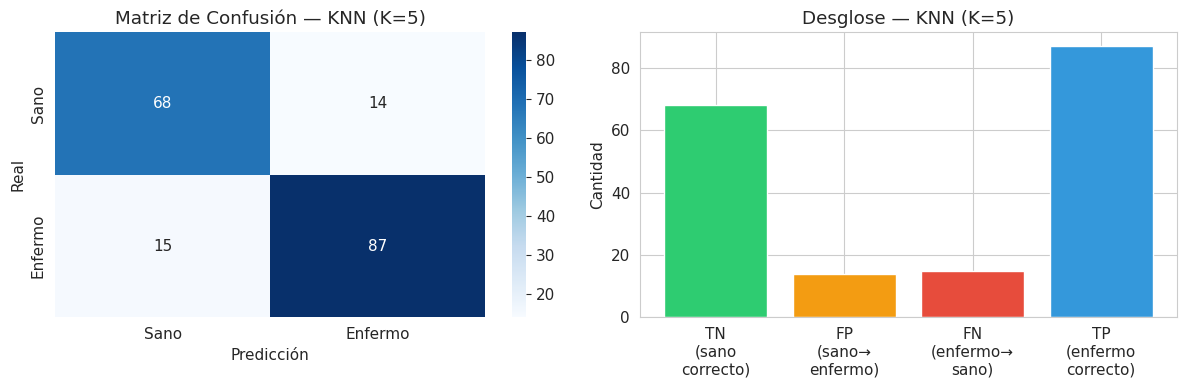


  FN (enfermo NO detectado): 15   ← error más costoso
  FP (sano marcado enfermo): 14

Reporte completo:
              precision    recall  f1-score   support

        Sano       0.82      0.83      0.82        82
     Enfermo       0.86      0.85      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [28]:
# 8.2  Evaluación completa
_ = eval_classifier(pipe_knn, X_test, y_test, 'KNN (K=5)')

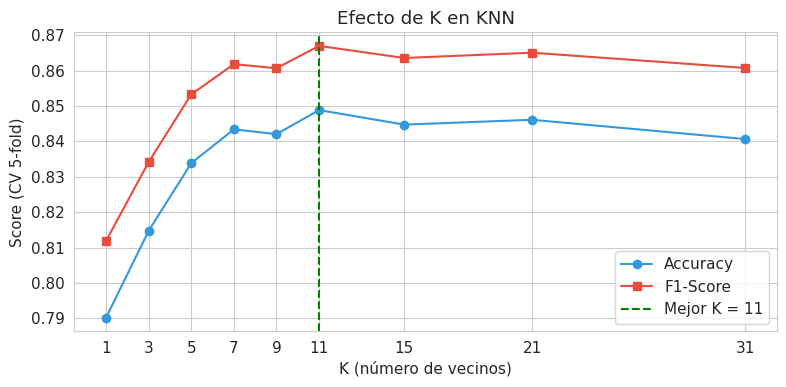

Mejor K por F1: 11   |   K empírico (√n): 27


In [29]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_f1, k_acc = [], []
for k in k_values:
    r = cross_validate(make_pipe(KNeighborsClassifier(n_neighbors=k), scale=True),
                       X_train, y_train, cv=skf, scoring=['accuracy', 'f1'])
    k_acc.append(r['test_accuracy'].mean()); k_f1.append(r['test_f1'].mean())

best_k = k_values[int(np.argmax(k_f1))]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_f1, 's-', label='F1-Score', color='#e74c3c')
ax.axvline(best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)'); ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.set_xticks(k_values); ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor K por F1: {best_k}   |   K empírico (√n): {int(np.sqrt(len(X_train)))}')

In [30]:
# 8.4  Comparación de métricas de distancia
for d, p in [('euclidean', 2), ('manhattan', 1), ('minkowski', 3)]:
    r = cross_validate(make_pipe(KNeighborsClassifier(n_neighbors=5, metric='minkowski' if d != 'euclidean' else d, p=p), scale=True),
                       X_train, y_train, cv=skf, scoring='f1')
    print(f'  Distancia {d:10s} (p={p}): F1 = {r["test_score"].mean():.4f}')

  Distancia euclidean  (p=2): F1 = 0.8533


  Distancia manhattan  (p=1): F1 = 0.8689


  Distancia minkowski  (p=3): F1 = 0.8523


---
## 9. Modelo 5 (adicional) — Random Forest

**Fundamento:** Ensamble de árboles de decisión entrenados sobre muestras *bootstrap* del train y con un subconjunto aleatorio de features en cada división (*bagging* + decorrelación). La predicción final es el voto de todos los árboles, lo que **reduce la varianza** del árbol individual sin aumentar mucho el sesgo. No requiere estandarización.

**¿Por qué Random Forest para este dataset?** Datos tabulares mixtos (numéricos + categóricos), relaciones no lineales e interacciones (p. ej. `ST_Slope` × `ExerciseAngina`), tamaño moderado y valores atípicos: escenario donde los ensambles de árboles suelen destacar.

In [31]:
# 9.1  Pipeline + validación cruzada
pipe_rf = make_pipe(RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                           random_state=RANDOM_STATE, n_jobs=-1), scale=False)
cv_report(pipe_rf, 'Random Forest')

pipe_rf.fit(X_train, y_train)
MODELS['Random Forest'] = pipe_rf

Random Forest — Cross-Validation (5-fold)
  Accuracy  : 0.8570 ± 0.0300
  Precision : 0.8518 ± 0.0421
  Recall    : 0.9016 ± 0.0316
  F1-Score  : 0.8749 ± 0.0233
  AUC       : 0.9303 ± 0.0268


=== Random Forest ===
  Accuracy: 0.8696
  Precision: 0.8750
  Recall: 0.8922
  F1-Score: 0.8835
  AUC: 0.9260


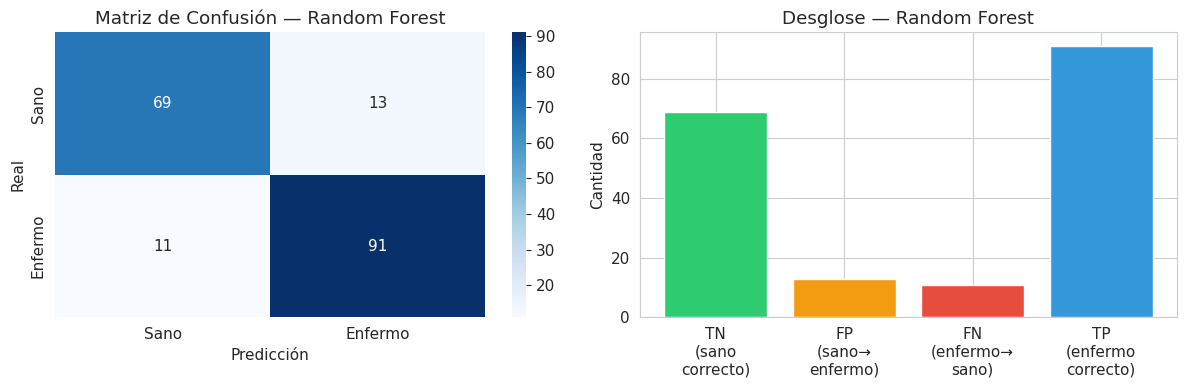


  FN (enfermo NO detectado): 11   ← error más costoso
  FP (sano marcado enfermo): 13

Reporte completo:
              precision    recall  f1-score   support

        Sano       0.86      0.84      0.85        82
     Enfermo       0.88      0.89      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [32]:
# 9.2  Evaluación completa
_ = eval_classifier(pipe_rf, X_test, y_test, 'Random Forest')

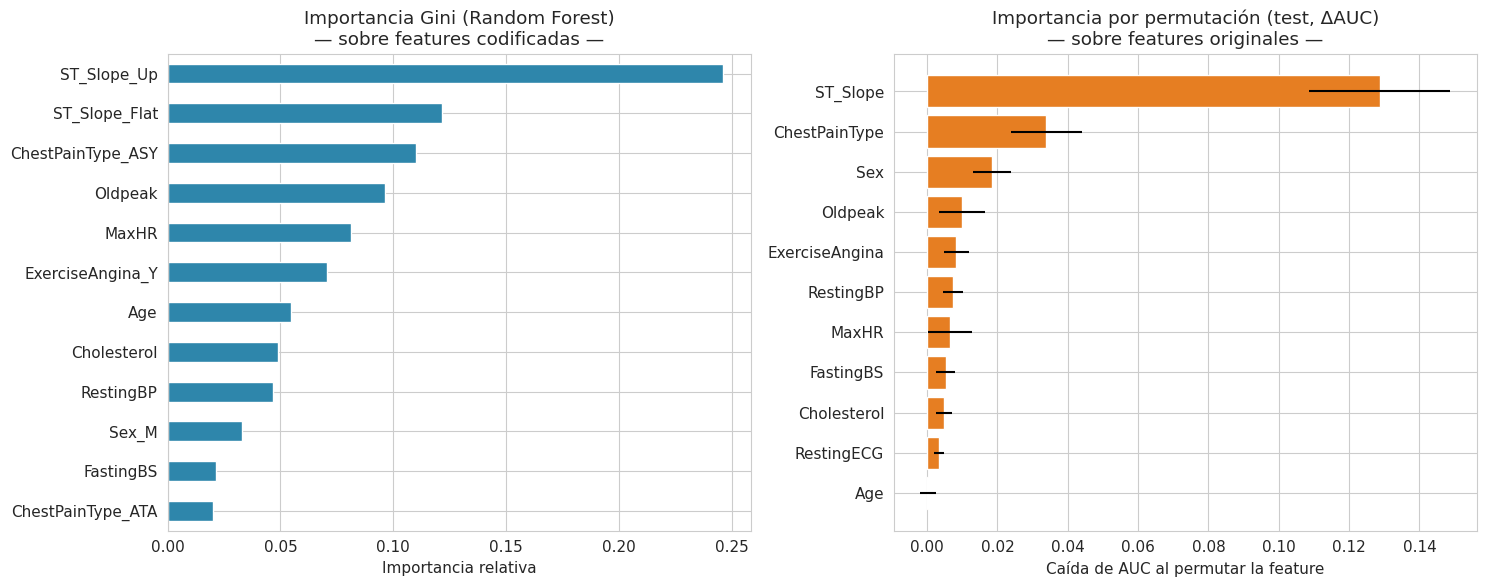

Top 3 por permutación: ['ST_Slope', 'ChestPainType', 'Sex']


In [33]:
# 9.3  Importancia de features: Gini (sesgada) vs Permutación (más fiable)
imp_gini = pd.Series(pipe_rf.named_steps['clf'].feature_importances_,
                     index=feat_names(pipe_rf)).sort_values()

perm = permutation_importance(pipe_rf, X_test, y_test, scoring='roc_auc',
                              n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
imp_gini.tail(12).plot(kind='barh', ax=axes[0], color='#2E86AB')
axes[0].set_title('Importancia Gini (Random Forest)\n— sobre features codificadas —')
axes[0].set_xlabel('Importancia relativa')
axes[1].barh(imp_perm.index, imp_perm.values, xerr=pd.Series(perm.importances_std, index=X_test.columns)[imp_perm.index],
             color='#e67e22')
axes[1].set_title('Importancia por permutación (test, ΔAUC)\n— sobre features originales —')
axes[1].set_xlabel('Caída de AUC al permutar la feature')
plt.tight_layout()
plt.show()
print('Top 3 por permutación:', imp_perm.tail(3).index.tolist()[::-1])

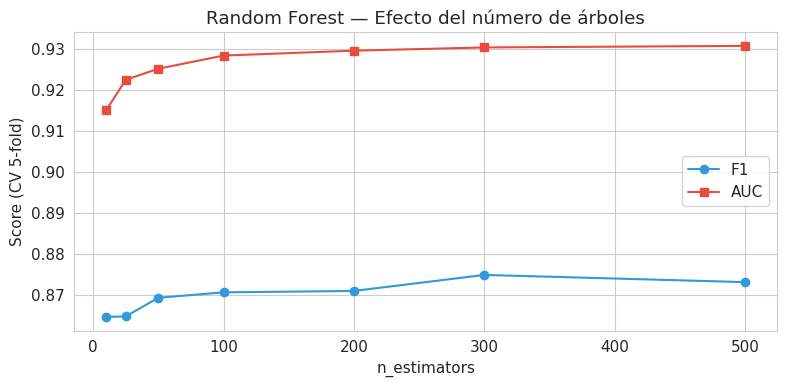

→ El rendimiento se estabiliza: más árboles no sobreajustan, solo cuestan más tiempo.


In [34]:
# 9.4  Efecto del número de árboles
n_list = [10, 25, 50, 100, 200, 300, 500]
n_f1, n_auc = [], []
for n in n_list:
    r = cross_validate(make_pipe(RandomForestClassifier(n_estimators=n, min_samples_leaf=3,
                                                        random_state=RANDOM_STATE, n_jobs=-1), scale=False),
                       X_train, y_train, cv=skf, scoring=['f1', 'roc_auc'])
    n_f1.append(r['test_f1'].mean()); n_auc.append(r['test_roc_auc'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_list, n_f1, 'o-', label='F1', color='#3498db')
ax.plot(n_list, n_auc, 's-', label='AUC', color='#e74c3c')
ax.set_xlabel('n_estimators'); ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Random Forest — Efecto del número de árboles')
ax.legend()
plt.tight_layout()
plt.show()
print('→ El rendimiento se estabiliza: más árboles no sobreajustan, solo cuestan más tiempo.')

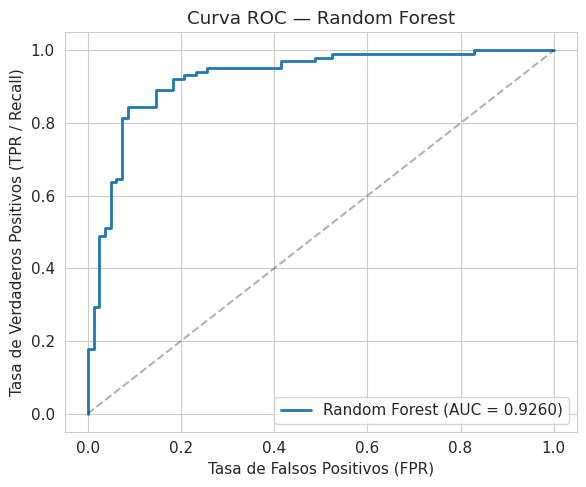

AUC: 0.9260


In [35]:
# 9.5  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_rf = plot_roc(pipe_rf, X_test, y_test, 'Random Forest', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_rf:.4f}')

---
## 10. Comparación final de los 5 modelos

In [36]:
# 10.1  Tabla de métricas en TEST (con IC 95% bootstrap del AUC)
def auc_ci(y_true, y_score, n_boot=1000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true); aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    return np.percentile(aucs, [2.5, 97.5])

rows = {}
for name, model in MODELS.items():
    lo, hi = auc_ci(y_test, get_score(model, X_test))
    rows[name] = {**METRICS[name], 'AUC IC95% (bootstrap)': f'[{lo:.3f}, {hi:.3f}]'}

metrics_df = pd.DataFrame(rows).T
num_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
metrics_df[num_cols] = metrics_df[num_cols].astype(float).round(4)
print('=== Tabla comparativa de métricas (Test Set, n =', len(y_test), ') ===')
metrics_df

=== Tabla comparativa de métricas (Test Set, n = 184 ) ===


,Accuracy,Precision,Recall,F1-Score,AUC,AUC IC95% (bootstrap)
Regresión Logística,0.8859,0.8857,0.9118,0.8986,0.9322,"[0.895, 0.964]"
Árbol de Decisión,0.7826,0.8229,0.7745,0.7980,0.8505,"[0.784, 0.904]"
SVM (RBF),0.8641,0.8738,0.8824,0.8780,0.9359,"[0.896, 0.967]"
KNN (K=5),0.8424,0.8614,0.8529,0.8571,0.9278,"[0.885, 0.962]"
Random Forest,0.8696,0.8750,0.8922,0.8835,0.9260,"[0.883, 0.962]"


In [37]:
# 10.2  Validación cruzada (train): media ± desv. y tiempos
cv_rows = {}
for name, r in CV.items():
    cv_rows[name] = {
        'Accuracy': f'{r["test_accuracy"].mean():.3f} ± {r["test_accuracy"].std():.3f}',
        'Precision': f'{r["test_precision"].mean():.3f} ± {r["test_precision"].std():.3f}',
        'Recall': f'{r["test_recall"].mean():.3f} ± {r["test_recall"].std():.3f}',
        'F1': f'{r["test_f1"].mean():.3f} ± {r["test_f1"].std():.3f}',
        'AUC': f'{r["test_roc_auc"].mean():.3f} ± {r["test_roc_auc"].std():.3f}',
        'Train F1 (media)': f'{np.mean(r["train_f1"]):.3f}',
        'Tiempo fit (s)': round(r['fit_time'].mean(), 4),
        'Tiempo pred (s)': round(r['score_time'].mean(), 4),
    }
cv_df = pd.DataFrame(cv_rows).T
print('=== Validación cruzada 5-fold (solo train) ===')
cv_df

=== Validación cruzada 5-fold (solo train) ===


,Accuracy,Precision,Recall,F1,AUC,Train F1 (media),Tiempo fit (s),Tiempo pred (s)
Regresión Logística,0.847 ± 0.030,0.862 ± 0.046,0.867 ± 0.022,0.863 ± 0.023,0.922 ± 0.035,0.873,0.0164,0.0216
Árbol de Decisión,0.807 ± 0.027,0.852 ± 0.045,0.793 ± 0.058,0.819 ± 0.027,0.870 ± 0.038,0.901,0.0147,0.0245
SVM (RBF),0.850 ± 0.036,0.850 ± 0.052,0.892 ± 0.028,0.869 ± 0.026,0.917 ± 0.033,0.906,0.0402,0.0255
KNN (K=5),0.834 ± 0.054,0.844 ± 0.065,0.865 ± 0.022,0.853 ± 0.042,0.897 ± 0.039,0.888,0.0138,0.0292
Random Forest,0.857 ± 0.030,0.852 ± 0.042,0.902 ± 0.032,0.875 ± 0.023,0.930 ± 0.027,0.944,0.4179,0.0652


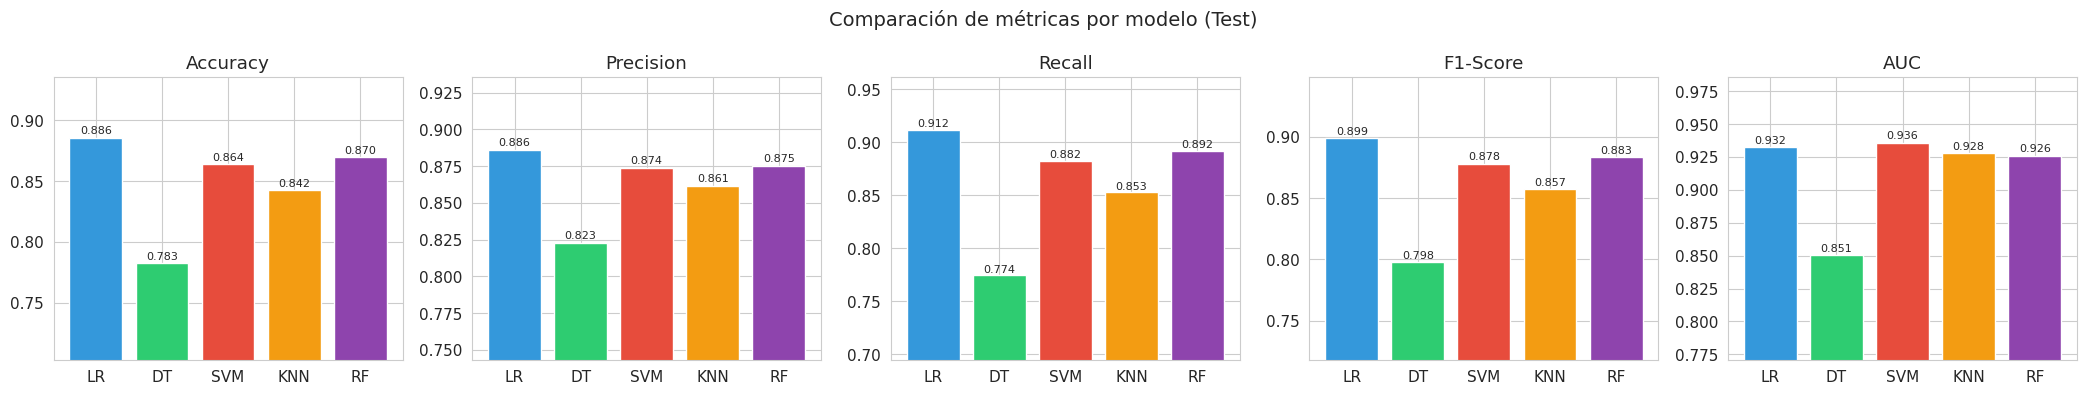

In [38]:
# 10.3  Gráfico de barras comparativo (test)
fig, axes = plt.subplots(1, 5, figsize=(21, 4))
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#8e44ad']
abbr = ['LR', 'DT', 'SVM', 'KNN', 'RF']
for i, metric in enumerate(num_cols):
    vals = metrics_df[metric].values
    axes[i].bar(range(len(vals)), vals, color=colors_models)
    for j, v in enumerate(vals):
        axes[i].text(j, v + 0.003, f'{v:.3f}', ha='center', fontsize=8)
    axes[i].set_title(metric)
    axes[i].set_ylim(max(0.0, vals.min() - 0.08), min(1.02, vals.max() + 0.05))
    axes[i].set_xticks(range(len(vals))); axes[i].set_xticklabels(abbr)
plt.suptitle('Comparación de métricas por modelo (Test)', fontsize=14)
plt.tight_layout()
plt.show()

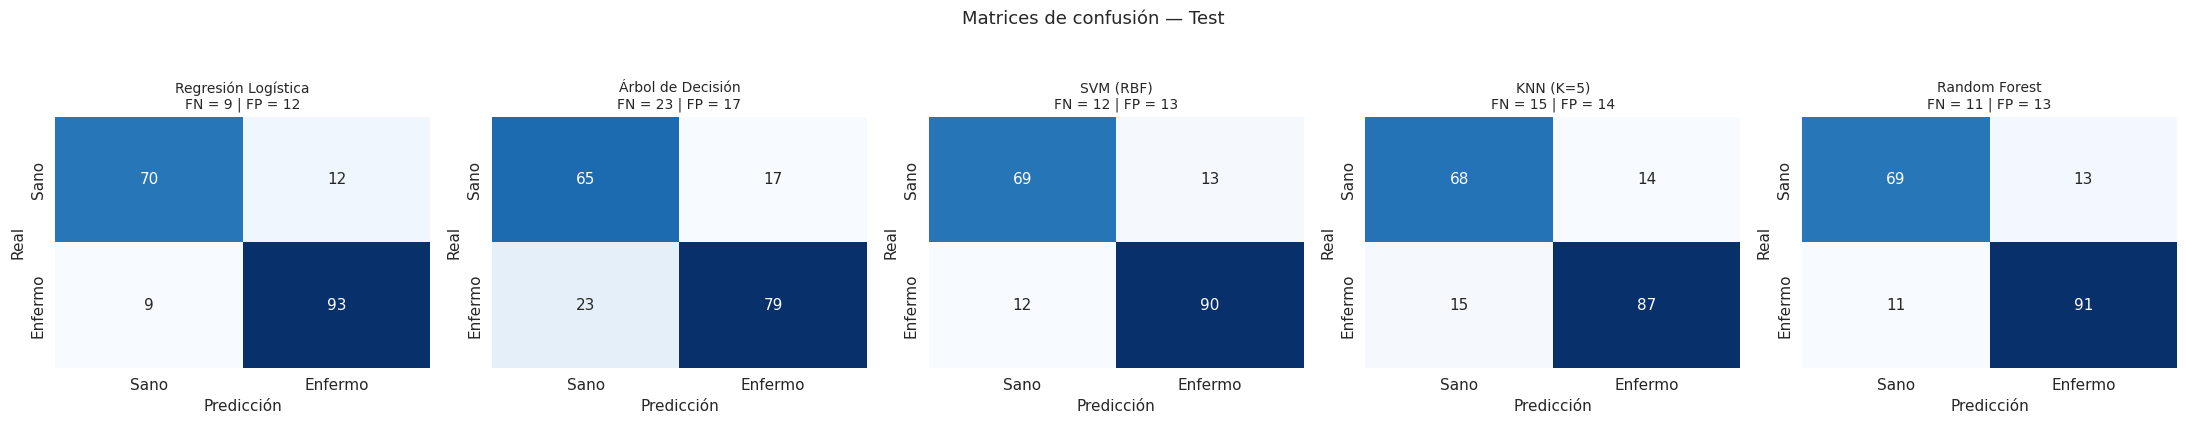

In [39]:
# 10.4  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, model) in zip(axes, MODELS.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'])
    ax.set_title(f'{name}\nFN = {cm[1, 0]} | FP = {cm[0, 1]}', fontsize=10)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.suptitle('Matrices de confusión — Test', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

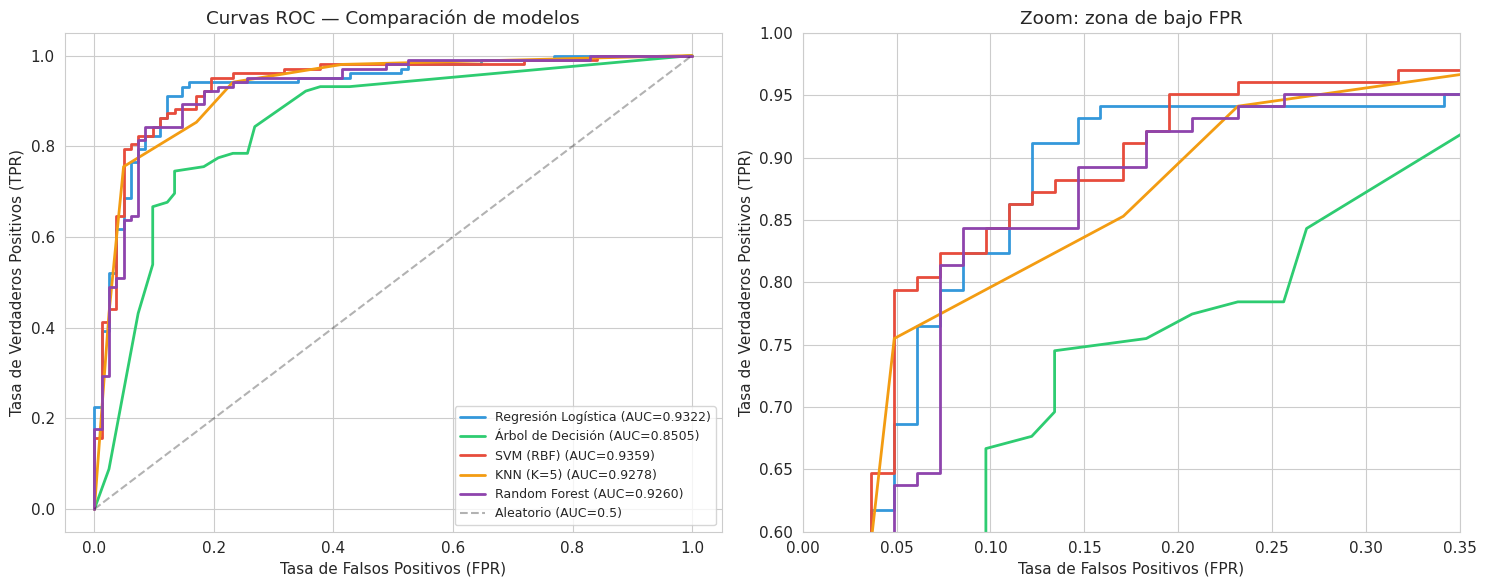

In [40]:
# 10.5  Curvas ROC superpuestas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, zoom in zip(axes, [False, True]):
    for (name, model), color in zip(MODELS.items(), colors_models):
        fpr, tpr, _ = roc_curve(y_test, get_score(model, X_test))
        ax.plot(fpr, tpr, linewidth=2, color=color, label=f'{name} (AUC={auc(fpr, tpr):.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    if zoom:
        ax.set_xlim(0, 0.35); ax.set_ylim(0.6, 1.0)
        ax.set_title('Zoom: zona de bajo FPR')
    else:
        ax.set_title('Curvas ROC — Comparación de modelos')
        ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

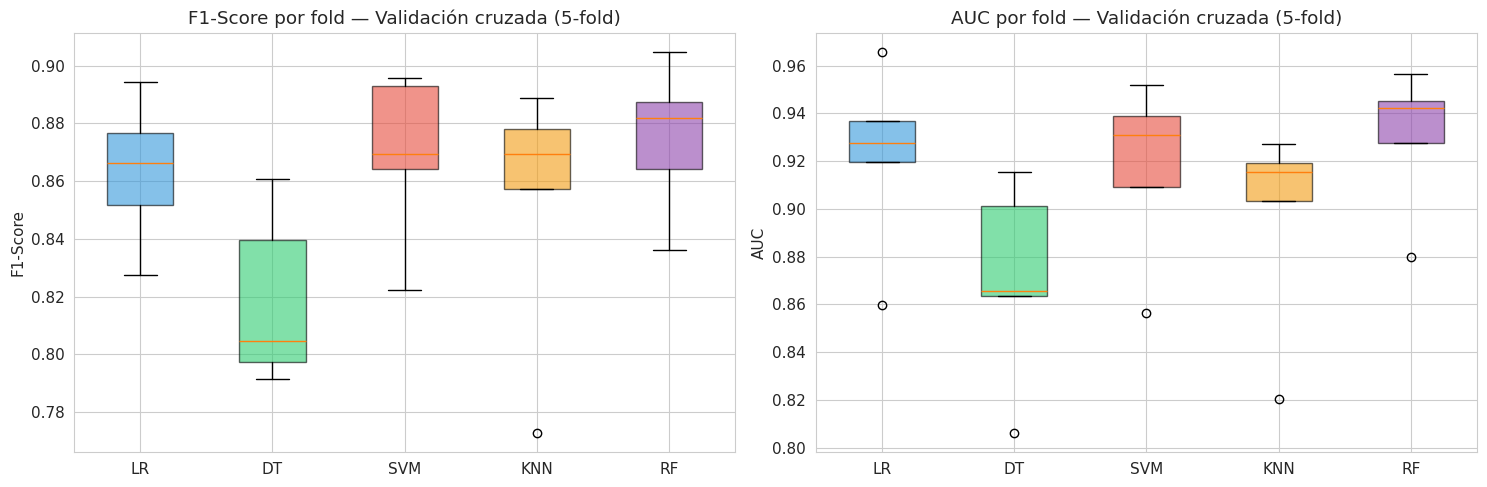

In [41]:
# 10.6  Distribución de F1 y AUC por fold (estabilidad)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, met, title in zip(axes, ['test_f1', 'test_roc_auc'], ['F1-Score', 'AUC']):
    bp = ax.boxplot([CV[n][met] for n in CV], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors_models):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_xticklabels(abbr)
    ax.set_ylabel(title)
    ax.set_title(f'{title} por fold — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

### Análisis de la comparación (secciones 10.1–10.6)

- **El Árbol de Decisión es claramente el peor modelo:** AUC ≈ 0.85 en test, Recall 0.77 (**23 falsos negativos** de 102 enfermos) y una brecha train–validación notable (F1 0.90 vs 0.82). Un árbol individual tiene alta varianza; **Random Forest, que es un ensamble de árboles, reduce los falsos negativos de 23 a 11** y sube el AUC de 0.85 a 0.93: es el efecto directo del *bagging*.
- **Los otros cuatro modelos forman un grupo compacto:** AUC en test entre 0.926 y 0.936 y en validación cruzada entre 0.897 y 0.930. Los **intervalos de confianza bootstrap del AUC se solapan casi por completo** (p. ej. [0.895, 0.964] para Regresión Logística vs [0.883, 0.962] para Random Forest), por lo que **las diferencias entre ellos no son estadísticamente concluyentes** con solo 184 pacientes de test (un paciente mal clasificado mueve el Recall ≈ 1 punto).
- **El orden cambia entre CV y test:** en test la Regresión Logística lidera en F1 (0.899) y Recall (0.912); en validación cruzada (734 pacientes, más fiable) lidera Random Forest (F1 0.875, AUC 0.930, Recall 0.902). Esta inconsistencia es la señal típica de que las diferencias son ruido.
- **Los modelos no lineales no aportan ventaja clara sobre la Regresión Logística**, lo que sugiere que la señal de este dataset es en gran parte aditiva/lineal en las variables codificadas.
- **Estabilidad:** KNN es el menos estable (F1 ± 0.042, AUC ± 0.039) y el Árbol tiene la mayor variabilidad en Recall (± 0.058). Regresión Logística y Random Forest son los más estables.
- **Costo computacional:** Random Forest tarda ≈ 0.38 s en entrenar frente a ≈ 0.015 s de la Regresión Logística (≈ 25×): irrelevante con 918 filas, pero relevante a escala.

### 10.7 Matriz de selección ponderada

Se evalúan los modelos en **6 criterios** con escala 1–5 (5 = mejor). Los criterios de **rendimiento, estabilidad y velocidad** se calculan con los **datos medidos** (validación cruzada) reescalados a 1–5 por min-max; **interpretabilidad** y **robustez a outliers** son juicios del analista basados en las propiedades de cada algoritmo (ver sección 11).

| Criterio | Fuente | Justificación de su peso |
|---|---|---|
| AUC (CV) | medido | Capacidad discriminante global, independiente del umbral |
| Recall (CV) | medido | En diagnóstico, el falso negativo es el error más costoso |
| Estabilidad | medido (1/σ del F1 por fold) | Un modelo clínico debe rendir parecido en pacientes distintos |
| Interpretabilidad | juicio | Un médico necesita entender por qué se predice riesgo |
| Velocidad | medido (fit + predicción) | Costo de reentrenar y de desplegar |
| Robustez a outliers | juicio | Datos clínicos con valores atípicos y errores de captura |

Como la elección depende de los pesos, se hace un **análisis de sensibilidad** con tres perfiles de decisión.

In [42]:
def to_1_5(s):
    """Reescala una serie a [1, 5] por min-max (mayor = mejor)."""
    return 1 + 4 * (s - s.min()) / (s.max() - s.min())

names = list(CV.keys())
interp = {'Regresión Logística': 4, 'Árbol de Decisión': 5, 'SVM (RBF)': 2, 'KNN (K=5)': 3, 'Random Forest': 3}
robust = {'Regresión Logística': 3, 'Árbol de Decisión': 4, 'SVM (RBF)': 4, 'KNN (K=5)': 2, 'Random Forest': 5}

raw = pd.DataFrame(index=names)
raw['AUC (CV)']          = [CV[n]['test_roc_auc'].mean() for n in names]
raw['Recall (CV)']       = [CV[n]['test_recall'].mean() for n in names]
raw['Estabilidad']       = [-CV[n]['test_f1'].std() for n in names]
raw['Velocidad']         = [-np.log10(CV[n]['fit_time'].mean() + CV[n]['score_time'].mean()) for n in names]

sel = raw.apply(to_1_5)
sel['Interpretabilidad'] = pd.Series(interp)
sel['Robustez outliers'] = pd.Series(robust)
sel = sel[['AUC (CV)', 'Recall (CV)', 'Estabilidad', 'Interpretabilidad', 'Velocidad', 'Robustez outliers']]

perfiles = {
    'Base':            [0.25, 0.20, 0.10, 0.20, 0.15, 0.10],
    'Clínico (riesgo)':[0.35, 0.30, 0.10, 0.10, 0.05, 0.10],
    'Explicabilidad':  [0.15, 0.15, 0.10, 0.40, 0.10, 0.10],
}
for p, w in perfiles.items():
    assert abs(sum(w) - 1) < 1e-9

pesos_df = pd.DataFrame(perfiles, index=sel.columns).T
print('Pesos por perfil de decisión:')
display(pesos_df.style.format('{:.0%}'))

sel_show = sel.copy()
sel_show['PUNTAJE (Base)'] = sel.values @ np.array(perfiles['Base'])
print('\n=== Matriz de selección (escala 1–5, perfil Base) ===')
display(sel_show.round(2).sort_values('PUNTAJE (Base)', ascending=False)
        .style.background_gradient(cmap='RdYlGn', vmin=1, vmax=5))

Pesos por perfil de decisión:


,AUC (CV),Recall (CV),Estabilidad,Interpretabilidad,Velocidad,Robustez outliers
Base,25%,20%,10%,20%,15%,10%
Clínico (riesgo),35%,30%,10%,10%,5%,10%
Explicabilidad,15%,15%,10%,40%,10%,10%



=== Matriz de selección (escala 1–5, perfil Base) ===


,AUC (CV),Recall (CV),Estabilidad,Interpretabilidad,Velocidad,Robustez outliers,PUNTAJE (Base)
Regresión Logística,4.440000,3.730000,5.000000,4,5.000000,3,4.210000
Random Forest,5.000000,5.000000,4.850000,3,1.000000,5,3.990000
SVM (RBF),4.140000,4.640000,4.200000,2,4.140000,4,3.800000
KNN (K=5),2.790000,3.630000,1.000000,3,4.810000,2,3.050000
Árbol de Decisión,1.000000,1.000000,4.130000,5,4.960000,4,3.010000


=== Análisis de sensibilidad: puntaje (1–5) y ranking por perfil ===


,Base,Clínico (riesgo),Explicabilidad,Rank Base,Rank Clínico (riesgo),Rank Explicabilidad
Regresión Logística,4.21,4.12,4.12,1,2,1
Random Forest,3.99,4.59,3.79,2,1,2
SVM (RBF),3.80,4.07,3.35,3,3,4
KNN (K=5),3.05,2.91,2.95,4,4,5
Árbol de Decisión,3.01,2.21,3.61,5,5,3


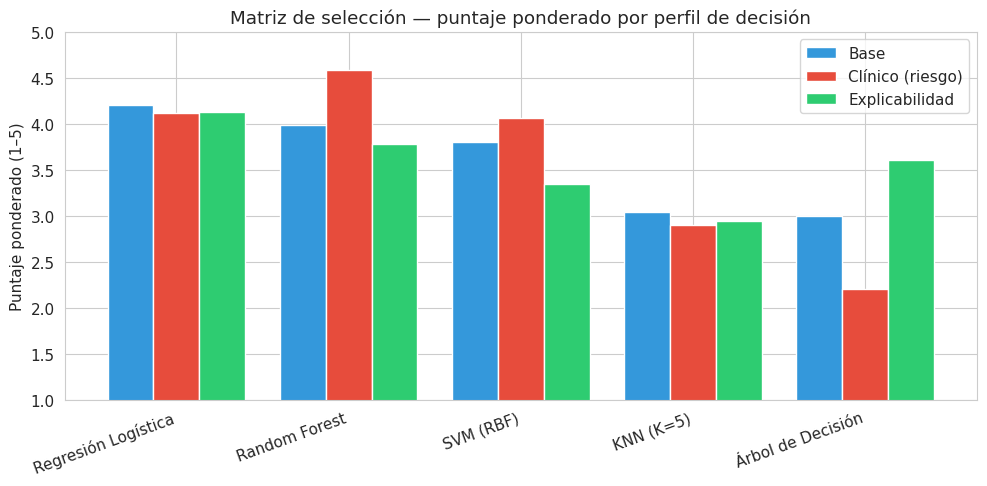


★ Mejor modelo según perfil Base: Regresión Logística
  Ganador por perfil: {'Base': 'Regresión Logística', 'Clínico (riesgo)': 'Random Forest', 'Explicabilidad': 'Regresión Logística'}


In [43]:
# Sensibilidad: puntaje total y ranking bajo cada perfil
tot = pd.DataFrame({p: sel.values @ np.array(w) for p, w in perfiles.items()}, index=sel.index)
rank = tot.rank(ascending=False).astype(int).add_prefix('Rank ')
sens = pd.concat([tot.round(2), rank], axis=1).sort_values('Base', ascending=False)
print('=== Análisis de sensibilidad: puntaje (1–5) y ranking por perfil ===')
display(sens)

fig, ax = plt.subplots(figsize=(10, 5))
tot.loc[sens.index].plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'], width=0.8)
ax.set_ylabel('Puntaje ponderado (1–5)'); ax.set_ylim(1, 5)
ax.set_title('Matriz de selección — puntaje ponderado por perfil de decisión')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

MEJOR = sens.index[0]
print(f'\n★ Mejor modelo según perfil Base: {MEJOR}')
print('  Ganador por perfil:', {p: tot[p].idxmax() for p in perfiles})

### 10.8 Justificación del mejor modelo

In [44]:
# Reporte detallado del modelo elegido (test)
best_model = MODELS[MEJOR]
y_pred_best = best_model.predict(X_test)
cm_b = confusion_matrix(y_test, y_pred_best)
lo, hi = auc_ci(y_test, get_score(best_model, X_test))

print(f'Modelo seleccionado: {MEJOR}')
print('=' * 60)
print(classification_report(y_test, y_pred_best, target_names=['Sano', 'Enfermo']))
print(f'AUC test = {METRICS[MEJOR]["AUC"]:.4f}   IC95% bootstrap = [{lo:.3f}, {hi:.3f}]')
print(f'AUC CV   = {CV[MEJOR]["test_roc_auc"].mean():.4f} ± {CV[MEJOR]["test_roc_auc"].std():.4f}')
print(f'\nDe {cm_b[1].sum()} pacientes enfermos en test: {cm_b[1, 1]} detectados, {cm_b[1, 0]} no detectados (FN).')
print(f'De {cm_b[0].sum()} pacientes sanos en test: {cm_b[0, 0]} correctos, {cm_b[0, 1]} falsas alarmas (FP).')

Modelo seleccionado: Regresión Logística
              precision    recall  f1-score   support

        Sano       0.89      0.85      0.87        82
     Enfermo       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

AUC test = 0.9322   IC95% bootstrap = [0.895, 0.964]
AUC CV   = 0.9219 ± 0.0348

De 102 pacientes enfermos en test: 93 detectados, 9 no detectados (FN).
De 82 pacientes sanos en test: 70 correctos, 12 falsas alarmas (FP).


### Modelo seleccionado: **Regresión Logística** (alternativa: Random Forest)

**Argumentos a favor de la Regresión Logística**

1. **Rendimiento equivalente a los mejores.** En test obtiene el mayor F1 (0.899), Accuracy (0.886) y Recall (0.912, solo **9 falsos negativos** de 102 enfermos) con AUC 0.932. En validación cruzada su AUC (0.922 ± 0.035) es el segundo, a solo 0.008 de Random Forest, diferencia muy inferior a la desviación entre folds.
2. **Ningún modelo más complejo demuestra ser mejor.** Los IC 95 % del AUC de Regresión Logística, SVM, KNN y Random Forest se solapan casi totalmente; solo el Árbol de Decisión queda claramente por debajo. Ante un empate estadístico se aplica el **principio de parsimonia**.
3. **Generaliza de forma estable.** La brecha entre F1 de entrenamiento y validación es ≈ 1 punto (0.873 vs 0.863), frente a ≈ 7 puntos en Random Forest (0.944 vs 0.875), que sobreajusta más.
4. **Es interpretable:** los coeficientes y *odds ratios* (sección 5.3) permiten explicar a un profesional de la salud qué variables elevan o reducen el riesgo (p. ej. sexo masculino, dolor torácico asintomático y glucemia en ayunas elevada multiplican las odds de enfermedad por ≈ 3.7, 3.3 y 3.3; la pendiente ST ascendente y el dolor no anginoso o atípico las reducen). En un contexto clínico, poder auditar la predicción es un requisito, no un extra.
5. **Es la más rápida** de entrenar y desplegar.
6. **Matriz de selección:** gana con el perfil *Base* (4.18 vs 3.99 de Random Forest) y con el perfil *Explicabilidad* (4.11 vs 3.79), y es segunda en el perfil *Clínico*.

**Cuándo preferir Random Forest.** Si la prioridad absoluta fuera **maximizar la sensibilidad en un tamizaje** y la interpretabilidad no fuera un requisito, Random Forest es la mejor opción: gana el perfil *Clínico* (4.59 vs 4.11), tiene el mayor AUC (0.930), Recall (0.902) y F1 (0.875) en validación cruzada, y su importancia por permutación (sección 9.3) señala como variables clave `ST_Slope`, `ChestPainType` y `Sex`, coherentes con el EDA.

**Salvedades honestas**

- La evidencia es **mixta**: en CV el Recall de la Regresión Logística (0.867) es inferior al de Random Forest (0.902) y SVM (0.892), mientras que en test ocurre lo contrario. Con n = 184 no puede afirmarse que uno supere al otro.
- El resultado depende de los pesos de la matriz (por eso se incluye el análisis de sensibilidad) y de que interpretabilidad y robustez son juicios del analista.
- Si el criterio fuera solo el Recall, no hace falta cambiar de modelo: se puede **bajar el umbral de decisión** de la Regresión Logística sobre la curva ROC para reducir falsos negativos a cambio de más falsas alarmas.

---
## 11. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable (coeficientes y odds ratios), probabilística, muy rápida | Asume linealidad en los log-odds; no captura interacciones sin ingeniería de features | Baseline; cuando se exige explicar el efecto de cada variable |
| **Árbol de Decisión** | Reglas if-else explicables, tipos mixtos, sin estandarización | Alta varianza y sobreajuste sin poda; inestable | Reglas de negocio/protocolos clínicos explicables |
| **SVM (RBF)** | Fronteras no lineales, buen rendimiento con pocos datos | Sensible a escala, difícil de interpretar, costo O(n²–n³) | Datasets medianos con fronteras complejas |
| **KNN** | Simple, no paramétrico, sin fase de entrenamiento | Predicción lenta, sensible a escala y a dimensionalidad (one-hot la eleva) | Datasets pequeños con features bien escaladas |
| **Random Forest** | Reduce la varianza del árbol, captura no linealidades e interacciones, robusto a outliers, importancia de variables | Menos interpretable que un árbol; más lento; probabilidades no siempre calibradas | Datos tabulares mixtos donde prima el rendimiento |

**Criterio de selección final:** en diagnóstico cardíaco se prioriza **maximizar el Recall de la clase Enfermo** (minimizar falsos negativos) sin sacrificar demasiado la precisión, junto con un **AUC alto y estable**. La justificación numérica está en la sección 10.8.

---
## 12. Ejercicio 1 — Optimización con GridSearchCV

Búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')` para **cada modelo**, usando las grillas sugeridas en el enunciado (más una grilla para Random Forest). La búsqueda usa **solo el conjunto de entrenamiento**; el test se reserva para la comparación final.

In [45]:
# 12.1  Grillas de hiperparámetros
grids = {
    'Regresión Logística': (make_pipe(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), True),
                            {'clf__C': [0.01, 0.1, 1, 10, 100]}),
    'Árbol de Decisión':   (make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE), False),
                            {'clf__max_depth': [3, 5, 7, 10, None], 'clf__min_samples_leaf': [1, 5, 10]}),
    'SVM (RBF)':           (make_pipe(SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE), True),
                            {'clf__C': [0.1, 1, 10], 'clf__gamma': [0.001, 0.01, 0.1]}),
    'KNN (K=5)':           (make_pipe(KNeighborsClassifier(), True),
                            {'clf__n_neighbors': [3, 5, 9, 15, 21], 'clf__weights': ['uniform', 'distance']}),
    'Random Forest':       (make_pipe(RandomForestClassifier(min_samples_leaf=1, random_state=RANDOM_STATE, n_jobs=-1), False),
                            {'clf__n_estimators': [100, 300], 'clf__max_depth': [None, 5, 10], 'clf__min_samples_leaf': [1, 3, 5]}),
}

TUNED, GS = {}, {}
t0 = time.time()
for name, (pipe, grid) in grids.items():
    gs = GridSearchCV(pipe, grid, cv=skf, scoring='f1', n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    GS[name] = gs
    TUNED[name] = gs.best_estimator_
    n_comb = int(np.prod([len(v) for v in grid.values()]))
    print(f'{name:22s} | {n_comb:2d} combinaciones | mejor F1 CV = {gs.best_score_:.4f} | {gs.best_params_}')
print(f'\nTiempo total de búsqueda: {time.time() - t0:.1f} s')

Regresión Logística    |  5 combinaciones | mejor F1 CV = 0.8633 | {'clf__C': 1}


Árbol de Decisión      | 15 combinaciones | mejor F1 CV = 0.8475 | {'clf__max_depth': 5, 'clf__min_samples_leaf': 10}


SVM (RBF)              |  9 combinaciones | mejor F1 CV = 0.8707 | {'clf__C': 1, 'clf__gamma': 0.1}


KNN (K=5)              | 10 combinaciones | mejor F1 CV = 0.8664 | {'clf__n_neighbors': 21, 'clf__weights': 'distance'}


Random Forest          | 18 combinaciones | mejor F1 CV = 0.8749 | {'clf__max_depth': None, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 300}

Tiempo total de búsqueda: 34.2 s


In [46]:
# 12.2  Comparación base vs optimizado (test)
rows = []
for name in MODELS:
    base_m = METRICS[name]
    tuned = TUNED[name]
    yp = tuned.predict(X_test)
    t_m = {'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp),
           'Recall': recall_score(y_test, yp), 'F1-Score': f1_score(y_test, yp),
           'AUC': roc_auc_score(y_test, get_score(tuned, X_test))}
    rows.append({'Modelo': name,
                 'F1 CV base': CV[name]['test_f1'].mean(), 'F1 CV optimizado': GS[name].best_score_,
                 'F1 test base': base_m['F1-Score'], 'F1 test optimizado': t_m['F1-Score'],
                 'Recall test base': base_m['Recall'], 'Recall test optim.': t_m['Recall'],
                 'AUC test base': base_m['AUC'], 'AUC test optim.': t_m['AUC']})
    METRICS[name + ' [opt]'] = t_m

cmp_df = pd.DataFrame(rows).set_index('Modelo')
cmp_df['Δ F1 test'] = cmp_df['F1 test optimizado'] - cmp_df['F1 test base']
print('=== Modelos base vs optimizados con GridSearchCV ===')
display(cmp_df.round(4).style.background_gradient(subset=['Δ F1 test'], cmap='RdYlGn', vmin=-0.05, vmax=0.05))

best_params_df = pd.DataFrame({n: {k.replace('clf__', ''): v for k, v in GS[n].best_params_.items()} for n in GS}).T
print('\nMejores hiperparámetros:')
display(best_params_df)

=== Modelos base vs optimizados con GridSearchCV ===


,F1 CV base,F1 CV optimizado,F1 test base,F1 test optimizado,Recall test base,Recall test optim.,AUC test base,AUC test optim.,Δ F1 test
Modelo,,,,,,,,,
Regresión Logística,0.863300,0.863300,0.898600,0.898600,0.911800,0.911800,0.932200,0.932200,0.000000
Árbol de Decisión,0.818800,0.847500,0.798000,0.807900,0.774500,0.803900,0.850500,0.836900,0.009900
SVM (RBF),0.868900,0.870700,0.878000,0.878000,0.882400,0.882400,0.935900,0.937000,0.000000
KNN (K=5),0.853300,0.866400,0.857100,0.905500,0.852900,0.892200,0.927800,0.939400,0.048300
Random Forest,0.874900,0.874900,0.883500,0.883500,0.892200,0.892200,0.926000,0.926000,0.000000



Mejores hiperparámetros:


,C,max_depth,min_samples_leaf,gamma,n_neighbors,weights,n_estimators
Regresión Logística,1.0,NaN,NaN,NaN,NaN,NaN,NaN
Árbol de Decisión,NaN,5.0,10.0,NaN,NaN,NaN,NaN
SVM (RBF),1.0,NaN,NaN,0.1,NaN,NaN,NaN
KNN (K=5),NaN,NaN,NaN,NaN,21,distance,NaN
Random Forest,NaN,NaN,3.0,NaN,NaN,NaN,300.0


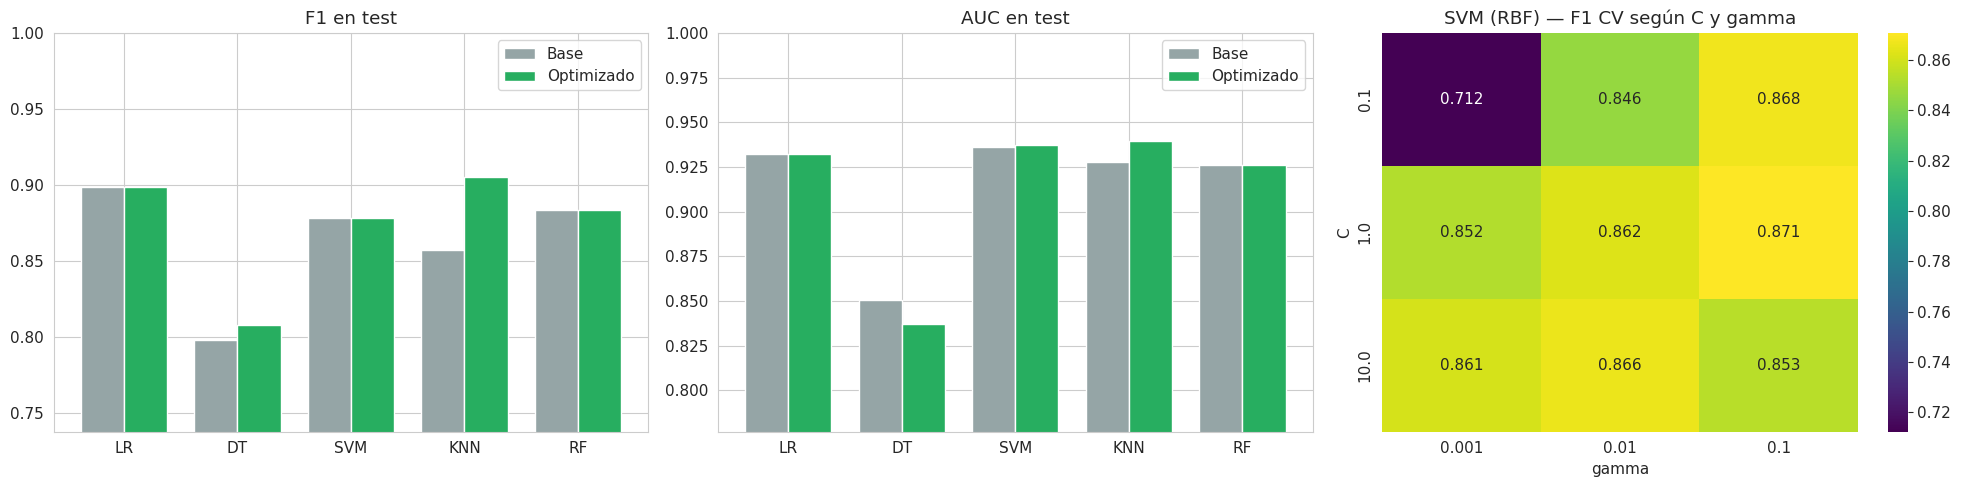

In [47]:
# 12.3  Visualización: base vs optimizado, y malla C×gamma de la SVM
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
x = np.arange(len(cmp_df)); w = 0.38
for ax, (b, o, t) in zip(axes[:2], [('F1 test base', 'F1 test optimizado', 'F1 en test'),
                                    ('AUC test base', 'AUC test optim.', 'AUC en test')]):
    ax.bar(x - w / 2, cmp_df[b], w, label='Base', color='#95a5a6')
    ax.bar(x + w / 2, cmp_df[o], w, label='Optimizado', color='#27ae60')
    ax.set_xticks(x); ax.set_xticklabels(abbr)
    ax.set_ylim(max(0, min(cmp_df[b].min(), cmp_df[o].min()) - 0.06), 1.0)
    ax.set_title(t); ax.legend()

res = pd.DataFrame(GS['SVM (RBF)'].cv_results_)
piv = res.pivot_table(index='param_clf__C', columns='param_clf__gamma', values='mean_test_score')
sns.heatmap(piv, annot=True, fmt='.3f', cmap='viridis', ax=axes[2])
axes[2].set_title('SVM (RBF) — F1 CV según C y gamma')
axes[2].set_xlabel('gamma'); axes[2].set_ylabel('C')
plt.tight_layout()
plt.show()

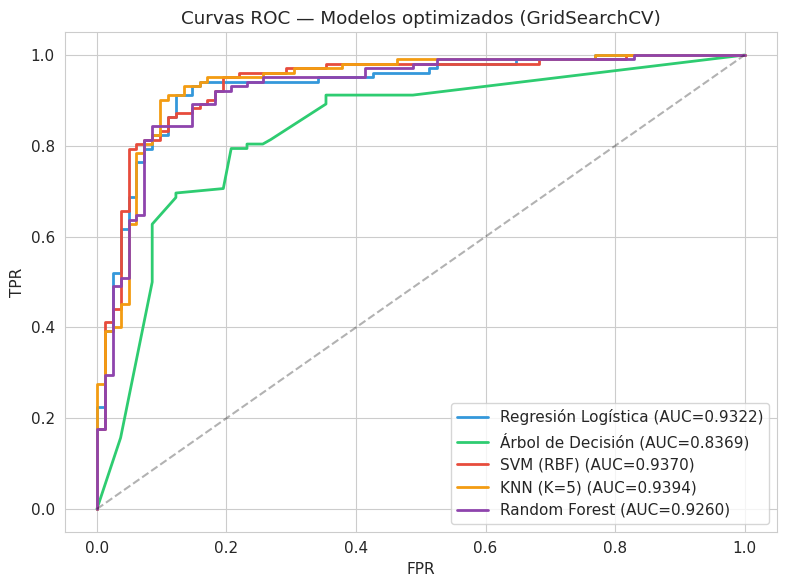

In [48]:
# 12.4  Curvas ROC de los modelos optimizados
fig, ax = plt.subplots(figsize=(8, 6))
for (name, model), color in zip(TUNED.items(), colors_models):
    fpr, tpr, _ = roc_curve(y_test, get_score(model, X_test))
    ax.plot(fpr, tpr, linewidth=2, color=color, label=f'{name} (AUC={auc(fpr, tpr):.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC — Modelos optimizados (GridSearchCV)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Análisis del Ejercicio 1

**Mejores hiperparámetros encontrados**

| Modelo | Mejor configuración | F1 CV base → optimizado | F1 test base → optimizado |
|---|---|---|---|
| Regresión Logística | `C = 1` (**igual al valor por defecto**) | 0.863 → 0.863 | 0.899 → 0.899 |
| Árbol de Decisión | `max_depth = 5`, `min_samples_leaf = 10` | 0.819 → 0.848 | 0.798 → 0.808 |
| SVM (RBF) | `C = 1`, `gamma = 0.1` | 0.869 → 0.871 | 0.878 → 0.878 |
| KNN | `n_neighbors = 21`, `weights = 'distance'` | 0.853 → 0.866 | 0.857 → 0.906 |
| Random Forest | `n_estimators = 300`, `max_depth = None`, `min_samples_leaf = 3` (**igual a la configuración base**) | 0.875 → 0.875 | 0.884 → 0.884 |

**Interpretación**

- **La optimización aporta poco en tres de los cinco modelos.** Regresión Logística y Random Forest ya partían de una configuración que la búsqueda vuelve a elegir, y la SVM mejora apenas 0.2 puntos de F1 en CV. Los valores por defecto de scikit-learn son razonables en datos de este tamaño y dimensión.
- **Los mayores beneficios están en los modelos de mayor varianza:** KNN pasa de K = 5 a K = 21 con ponderación por distancia (frontera más suave; F1 CV +1.3 puntos, F1 test +4.8, Recall test 0.853 → 0.892), y el Árbol mejora +2.9 puntos en CV al exigir hojas más grandes (menos sobreajuste), aunque su AUC en test empeora (0.850 → 0.837).
- **La SVM es sensible en la zona de infraajuste:** con `C = 0.1` y `gamma = 0.001` el F1 cae a 0.71, pero en el resto de la malla se mantiene en una meseta de 0.85–0.87; la elección exacta importa poco mientras no se cae en esa zona.
- **Cautela con la mejora de KNN en test:** +4.8 puntos sobre 184 pacientes equivale a unos pocos casos, y la mejora en CV es más modesta (+1.3). Además, `K = 21` y `min_samples_leaf = 10` están en el **borde de la grilla**, por lo que convendría ampliarla.
- **Sesgo optimista:** el `best_score_` de `GridSearchCV` se usó para elegir la configuración, por lo que sobrestima ligeramente el rendimiento real. Una estimación honesta requeriría *nested cross-validation*; aquí el conjunto de test cumple ese papel.
- **Tras optimizar, el ranking sigue sin ser concluyente:** en test lidera KNN (0.906), pero en CV lidera Random Forest (0.875). La conclusión de la sección 10.8 no cambia: los mejores modelos son estadísticamente indistinguibles.

---
## 13. Ejercicio 2 — Manejo de desbalance con `class_weight` y SMOTE

**Problema de partida:** Heart Failure está **casi balanceado** (55 % enfermos / 45 % sanos), por lo que se espera poco efecto de las técnicas de balanceo. Para que el ejercicio sea informativo se evalúan **dos escenarios**:

- **Escenario A — datos originales** (~55/45): ¿ayudan las técnicas cuando no hay desbalance real?
- **Escenario B — desbalance artificial**: se submuestrea la clase Enfermo en el train hasta ~15 %, imitando el caso clásico de la clase crítica minoritaria (como "maligno" en el ejemplo del enunciado).

**Estrategias comparadas:** (1) sin balanceo, (2) `class_weight='balanced'`, (3) SMOTE. KNN no admite `class_weight`, por lo que en él solo se compara sin balanceo vs SMOTE.

**Cuidado con la fuga de datos:** el ejemplo del enunciado aplica `fit_resample` sobre todo `X_train` *antes* de validar, lo que filtraría muestras sintéticas al fold de validación e inflaría las métricas. Aquí SMOTE va **dentro de un `imblearn.Pipeline`**, de modo que solo se aplica a los folds de entrenamiento. Se usa **validación cruzada repetida (5×3)** y solo se sintetiza sobre features ya preprocesadas.

In [49]:
# 13.1  Construcción de modelos por estrategia
CLF = {
    'Regresión Logística': lambda cw: LogisticRegression(max_iter=2000, class_weight=cw, random_state=RANDOM_STATE),
    'Árbol de Decisión':   lambda cw: DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5,
                                                             class_weight=cw, random_state=RANDOM_STATE),
    'SVM (RBF)':           lambda cw: SVC(kernel='rbf', C=1.0, class_weight=cw, random_state=RANDOM_STATE),
    'KNN (K=5)':           lambda cw: KNeighborsClassifier(n_neighbors=5),     # sin class_weight
    'Random Forest':       lambda cw: RandomForestClassifier(n_estimators=200, min_samples_leaf=3, class_weight=cw,
                                                             random_state=RANDOM_STATE, n_jobs=-1),
}
STRATS = ['Sin balanceo', 'class_weight', 'SMOTE']
cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

def build(name, strat):
    # Se escala para todos (los árboles son invariantes a la escala; SMOTE necesita features en escalas comparables)
    prep = make_prep(True)
    if strat == 'SMOTE':
        return ImbPipeline([('prep', prep), ('smote', SMOTE(random_state=RANDOM_STATE)), ('clf', CLF[name](None))])
    cw = 'balanced' if strat == 'class_weight' else None
    return Pipeline([('prep', prep), ('clf', CLF[name](cw))])

def run_strategies(Xs, ys, label):
    out = []
    for name in CLF:
        for strat in STRATS:
            if strat == 'class_weight' and name.startswith('KNN'):
                out.append({'Escenario': label, 'Modelo': name, 'Estrategia': strat,
                            'Recall': np.nan, 'Precision': np.nan, 'F1': np.nan, 'AUC': np.nan})
                continue
            r = cross_validate(build(name, strat), Xs, ys, cv=cv_rep, n_jobs=-1,
                               scoring=['recall', 'precision', 'f1', 'roc_auc'])
            out.append({'Escenario': label, 'Modelo': name, 'Estrategia': strat,
                        'Recall': r['test_recall'].mean(), 'Precision': r['test_precision'].mean(),
                        'F1': r['test_f1'].mean(), 'AUC': r['test_roc_auc'].mean()})
    return pd.DataFrame(out)

# Escenario A: datos originales (train)
t0 = time.time()
res_A = run_strategies(X_train, y_train, 'A: original (~55/45)')
print(f'Escenario A listo ({time.time() - t0:.0f} s)  —  proporción de enfermos: {y_train.mean():.1%}')

Escenario A listo (22 s)  —  proporción de enfermos: 55.3%


In [50]:
# Escenario B: desbalance artificial (clase Enfermo ≈ 15 %)
rng = np.random.RandomState(RANDOM_STATE)
neg_idx = y_train[y_train == 0].index
pos_idx = y_train[y_train == 1].index
n_pos = int(round(0.15 / 0.85 * len(neg_idx)))
keep = np.concatenate([neg_idx, rng.choice(pos_idx, n_pos, replace=False)])
X_imb, y_imb = X_train.loc[keep], y_train.loc[keep]

print(f'Escenario B: {len(y_imb)} muestras  |  Enfermos: {(y_imb == 1).sum()} ({y_imb.mean():.1%})  |  '
      f'Sanos: {(y_imb == 0).sum()}  |  Ratio {(y_imb == 0).sum() / (y_imb == 1).sum():.1f}:1')
t0 = time.time()
res_B = run_strategies(X_imb, y_imb, 'B: desbalance (~15% enfermos)')
print(f'Escenario B listo ({time.time() - t0:.0f} s)')

Escenario B: 386 muestras  |  Enfermos: 58 (15.0%)  |  Sanos: 328  |  Ratio 5.7:1


Escenario B listo (20 s)



=== A: original (~55/45) ===


Estrategia,Sin balanceo,class_weight,SMOTE
Modelo,,,
Regresión Logística,0.869000,0.844000,0.847000
Árbol de Decisión,0.819000,0.807000,0.819000
SVM (RBF),0.897000,0.883000,0.882000
KNN (K=5),0.879000,nan,0.846000
Random Forest,0.901000,0.892000,0.892000



=== B: desbalance (~15% enfermos) ===


Estrategia,Sin balanceo,class_weight,SMOTE
Modelo,,,
Regresión Logística,0.486000,0.772000,0.749000
Árbol de Decisión,0.533000,0.753000,0.661000
SVM (RBF),0.452000,0.688000,0.666000
KNN (K=5),0.539000,nan,0.774000
Random Forest,0.453000,0.655000,0.595000


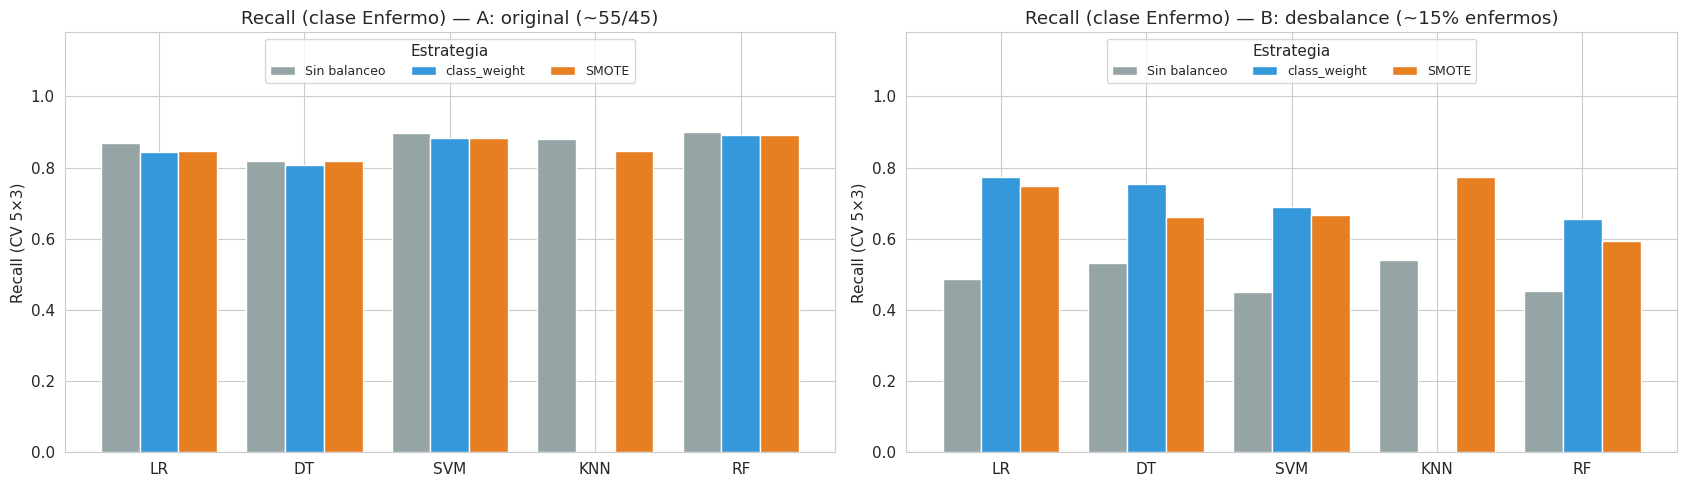

In [51]:
# 13.2  Resultados: Recall de la clase Enfermo (CV repetida 5×3)
res_all = pd.concat([res_A, res_B], ignore_index=True)
for esc, g in res_all.groupby('Escenario'):
    print(f'\n=== {esc} ===')
    display(g.pivot(index='Modelo', columns='Estrategia', values='Recall')[STRATS]
            .loc[list(CLF)].round(3).style.background_gradient(cmap='YlGn', axis=1))

fig, axes = plt.subplots(1, 2, figsize=(17, 5), sharey=False)
cols = {'Sin balanceo': '#95a5a6', 'class_weight': '#3498db', 'SMOTE': '#e67e22'}
for ax, (esc, g) in zip(axes, res_all.groupby('Escenario')):
    pv = g.pivot(index='Modelo', columns='Estrategia', values='Recall')[STRATS].loc[list(CLF)]
    pv.index = abbr
    pv.plot(kind='bar', ax=ax, color=[cols[s] for s in STRATS], width=0.8)
    ax.set_title(f'Recall (clase Enfermo) — {esc}')
    ax.set_ylabel('Recall (CV 5×3)'); ax.set_xlabel('')
    ax.set_ylim(0, 1.18); plt.setp(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Estrategia', loc='upper center', ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

In [52]:
# 13.3  Trade-off: Recall vs Precision vs F1 vs AUC (escenario B)
gB = res_B.copy()
gB['Δ Recall vs sin balanceo'] = gB.groupby('Modelo')['Recall'].transform(lambda s: s - s.iloc[0])
print('=== Escenario B (desbalance) — métricas completas ===')
display(gB.drop(columns='Escenario').set_index(['Modelo', 'Estrategia']).round(3))

print('\n=== Escenario A (original) — métricas completas ===')
display(res_A.drop(columns='Escenario').set_index(['Modelo', 'Estrategia']).round(3))

=== Escenario B (desbalance) — métricas completas ===


Recall  Precision     F1    AUC  \
Modelo              Estrategia                                      
Regresión Logística Sin balanceo   0.486      0.666  0.548  0.881   
                    class_weight   0.772      0.428  0.548  0.879   
                    SMOTE          0.749      0.452  0.560  0.871   
Árbol de Decisión   Sin balanceo   0.533      0.591  0.554  0.828   
                    class_weight   0.753      0.412  0.529  0.822   
                    SMOTE          0.661      0.544  0.584  0.821   
SVM (RBF)           Sin balanceo   0.452      0.796  0.565  0.884   
                    class_weight   0.688      0.484  0.564  0.892   
                    SMOTE          0.666      0.547  0.596  0.874   
KNN (K=5)           Sin balanceo   0.539      0.656  0.587  0.844   
                    class_weight     NaN        NaN    NaN    NaN   
                    SMOTE          0.774      0.428  0.549  0.864   
Random Forest       Sin balanceo   0.453      0.733  0.546  0.923   
                    class_weight   0.655      0.633  0.638  0.920   
                    SMOTE          0.595      0.600  0.589  0.913   

                                  Δ Recall vs sin balanceo  
Modelo              Estrategia                              
Regresión Logística Sin balanceo                     0.000  
                    class_weight                     0.286  
                    SMOTE                            0.263  
Árbol de Decisión   Sin balanceo                     0.000  
                    class_weight                     0.220  
                    SMOTE                            0.128  
SVM (RBF)           Sin balanceo                     0.000  
                    class_weight                     0.236  
                    SMOTE                            0.214  
KNN (K=5)           Sin balanceo                     0.000  
                    class_weight                       NaN  
                    SMOTE                            0.234  
Random Forest       Sin balanceo                     0.000  
                    class_weight                     0.202  
                    SMOTE                            0.142


=== Escenario A (original) — métricas completas ===


Recall  Precision     F1    AUC
Modelo              Estrategia                                   
Regresión Logística Sin balanceo   0.869      0.860  0.864  0.920
                    class_weight   0.844      0.863  0.852  0.920
                    SMOTE          0.847      0.863  0.854  0.919
Árbol de Decisión   Sin balanceo   0.819      0.839  0.827  0.876
                    class_weight   0.807      0.843  0.823  0.881
                    SMOTE          0.819      0.839  0.827  0.877
SVM (RBF)           Sin balanceo   0.897      0.849  0.872  0.915
                    class_weight   0.883      0.864  0.872  0.915
                    SMOTE          0.882      0.861  0.870  0.915
KNN (K=5)           Sin balanceo   0.879      0.842  0.860  0.894
                    class_weight     NaN        NaN    NaN    NaN
                    SMOTE          0.846      0.856  0.851  0.892
Random Forest       Sin balanceo   0.901      0.851  0.874  0.928
                    class_weight   0.892      0.860  0.875  0.928
                    SMOTE          0.892      0.865  0.878  0.928

### Análisis del Ejercicio 2

**Escenario A (datos originales, ~55/45): las técnicas de balanceo no ayudan.** El Recall de la clase Enfermo se mantiene igual o **baja ligeramente** con `class_weight` o SMOTE (p. ej. Regresión Logística 0.869 → 0.844/0.847; KNN 0.879 → 0.846 con SMOTE; Random Forest 0.901 → 0.892) y el AUC no cambia. Si las clases ya están equilibradas, reponderar o sintetizar muestras solo desplaza el umbral sin ganancia.

**Escenario B (~15 % de enfermos): el efecto es grande.** Sin balanceo, los modelos **pasan por alto a más de la mitad de los pacientes enfermos** (Recall 0.45–0.54) aunque su AUC sea alto (0.83–0.92); un modelo así lucería una accuracy engañosamente buena porque predecir "sano" siempre ya acierta ≈ 85 %.

| Modelo | Recall sin balanceo | Recall `class_weight` | Recall SMOTE | Precision (sin → `class_weight`) |
|---|---|---|---|---|
| Regresión Logística | 0.486 | **0.772** | 0.749 | 0.666 → 0.428 |
| Árbol de Decisión | 0.533 | **0.753** | 0.661 | 0.591 → 0.412 |
| SVM (RBF) | 0.452 | **0.688** | 0.666 | 0.796 → 0.484 |
| KNN | 0.539 | *(no admite)* | **0.774** | 0.656 → 0.428 (SMOTE) |
| Random Forest | 0.453 | **0.655** | 0.595 | 0.733 → 0.633 |

**Conclusiones**

1. **Ambas técnicas suben el Recall entre +0.20 y +0.29** en el escenario desbalanceado, pero **a costa de la Precision** (más falsas alarmas). Como el costo clínico de un falso negativo es mayor, el intercambio suele ser aceptable.
2. **El AUC casi no cambia** (p. ej. Regresión Logística 0.881 → 0.879 / 0.871; Random Forest 0.923 → 0.920 / 0.913): el balanceo **no mejora la capacidad de ordenar pacientes por riesgo, solo mueve el punto de operación** de la curva ROC. Por eso el mismo efecto puede lograrse ajustando el umbral de decisión.
3. **`class_weight='balanced'` iguala o supera a SMOTE en Recall** en 4 de 4 modelos comparables, sin generar datos sintéticos y con menor costo. SMOTE conserva algo más de Precision en el Árbol y la SVM (0.544 vs 0.412; 0.547 vs 0.484), es decir, es un poco menos agresivo.
4. **El F1 mejora poco en general**, salvo en **Random Forest con `class_weight`** (0.546 → 0.638), que además conserva el mejor AUC (0.92): es la combinación más equilibrada del escenario B.
5. **Salvedades:** el escenario B usa solo 386 muestras con 58 enfermos, por lo que hay más varianza (se compensa con validación cruzada repetida 5×3). SMOTE se aplicó sobre variables ya codificadas con one-hot, así que genera valores fraccionarios en las dummies; `SMOTENC` sería más fiel. Y, como se explicó, SMOTE va **dentro del pipeline** para no filtrar información al fold de validación.

---
## 14. Conclusiones generales

### Ejercicio 3 — Dataset propio (Heart Failure, 5 modelos)
- Se compararon **Regresión Logística, Árbol de Decisión, SVM, KNN y Random Forest** con validación cruzada 5-fold, métricas en test (Accuracy, Precision, Recall, F1, AUC con IC bootstrap), matrices de confusión, curvas ROC superpuestas y una **matriz de selección ponderada con análisis de sensibilidad**.
- Los cuatro mejores modelos alcanzan AUC ≈ 0.93 y **no pueden distinguirse estadísticamente** con 184 pacientes de test; el Árbol individual es el único claramente inferior.
- **Modelo recomendado: Regresión Logística** por rendimiento equivalente, estabilidad, interpretabilidad y bajo costo; **Random Forest** es la alternativa si se prioriza la sensibilidad y se acepta menor explicabilidad.

### Ejercicio 1 — GridSearchCV
- La optimización mejora sobre todo a los modelos de alta varianza (KNN, Árbol); Regresión Logística y Random Forest ya estaban cerca de su óptimo. Las mejoras en test son pequeñas frente al ruido muestral, y algunos óptimos caen en el borde de la grilla.

### Ejercicio 2 — Desbalance
- Con clases equilibradas, `class_weight` y SMOTE no aportan. Con desbalance (15 %), suben el Recall de la clase crítica en +0.20 a +0.29 a costa de Precision, sin mejorar el AUC: **cambian el punto de operación, no la capacidad de discriminar**. `class_weight` es la opción más simple y efectiva.

### Limitaciones
- **Tamaño y origen de los datos:** 918 pacientes de cinco hospitales/países distintos; el 88 % de los registros con colesterol = 0 son enfermos, lo que apunta a un sesgo de origen que un modelo podría aprovechar sin que sea un hallazgo clínico.
- **Incertidumbre de la evaluación:** con 184 pacientes de test, los IC 95 % del AUC miden ≈ ± 0.035.
- **Uso:** este trabajo es académico; no valida los modelos con datos externos ni con criterios regulatorios, y **no debe usarse como herramienta de diagnóstico**.

### Próximos pasos posibles
Elegir el umbral de decisión según un Recall objetivo (p. ej. ≥ 95 %), calibrar probabilidades, validación externa o *nested CV*, ampliar las grillas y explicar Random Forest con SHAP.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*

*Referencia del dataset: Soriano, F. (2021). Heart Failure Prediction Dataset. Kaggle. https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction. Este notebook tiene fines académicos y no constituye una herramienta de diagnóstico médico.*